In [1]:
import os
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings("ignore")

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
POS_PATH = "/Users/hajiyoon/workspace/data/processed/pos_data_food_final_상품단위변환전.parquet"
B4_PATH = "/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet"

def load_and_aggregate():
    """Polars Lazy Mode를 이용한 데이터 로딩 및 집계"""
    print(f"[1/5] 데이터 로딩 및 집계 중 (Polars Lazy Mode)...")
    
    # 1~5. 요구사항에 따른 Lazy 처리
    collected = (
        pl.scan_parquet(POS_PATH)
        .filter(
            (pl.col("매출수량") > 0) &
            (pl.col("매출금액") > 0)
        )
        .join(
            pl.scan_parquet(B4_PATH)
              .select(["상품코드", "중분류명", "소분류명", "상품명"]),
            on="상품코드", how="inner"
        )
        .group_by(["상품코드", "중분류명", "소분류명", "상품명"])
        .agg(
            pl.col("매출금액").sum().alias("총매출금액"),
            pl.col("매출수량").sum().alias("총매출수량")
        )
        .collect()
    )
    return collected.to_pandas()

def apply_pareto(df):
    """중분류별 파레토 80% 성공군 분류"""
    print(f"[2/5] 중분류별 파레토 80% 성공군 분류 중...")
    df = df.copy()
    df['pareto_label'] = 0

    for cat, group in df.groupby('중분류명'):
        # 매출금액 내림차순 정렬
        group_sorted = group.sort_values('총매출금액', ascending=False)

        # 누적 매출 비율 계산
        cumsum = group_sorted['총매출금액'].cumsum()
        total = group_sorted['총매출금액'].sum()
        
        if total <= 0: continue
        cum_ratio = cumsum / total

        # 누적 80% 이하인 상품 -> 성공(1)
        success_idx = group_sorted[cum_ratio <= 0.8].index

        # 정확히 80%가 되는 마지막 상품 포함
        if len(success_idx) < len(group_sorted):
            next_idx = group_sorted.index[len(success_idx)]
            success_idx = success_idx.append(pd.Index([next_idx]))

        df.loc[success_idx, 'pareto_label'] = 1

    return df

def aggregate_summary(df):
    """중분류별 성공군 통계 집계"""
    print(f"[3/5] 통계 집계 중...")
    summary = (
        df.groupby('중분류명')
        .agg(
            전체SKU수=('상품코드', 'count'),
            성공군수=('pareto_label', 'sum')
        )
        .reset_index()
    )
    summary['성공군비율(%)'] = (summary['성공군수'] / summary['전체SKU수'] * 100).round(2)
    return summary.sort_values('성공군비율(%)', ascending=False)

def print_summary(df_labeled, summary):
    """결과 콘솔 출력"""
    total_count = len(df_labeled)
    success_count = df_labeled['pareto_label'].sum()
    failure_count = total_count - success_count
    
    print("\n" + "="*55)
    print(" [파레토 80% 성공군 분류 결과]")
    print("="*55)
    print(f"전체 상품 수: {total_count:,}개")
    print(f"성공군 (pareto_label=1): {success_count:,}개 ({success_count/total_count*100:.1f}%)")
    print(f"실패군 (pareto_label=0): {failure_count:,}개 ({failure_count/total_count*100:.1f}%)")
    
    print("\n[중분류별 성공군 현황 - 상위 10개]")
    print(f"{'중분류명':<15} | {'전체SKU':>7} | {'성공군수':>7} | {'성공군비율(%)':>10}")
    print("-" * 60)
    for _, row in summary.head(10).iterrows():
        print(f"{row['중분류명']:<15} | {int(row['전체SKU수']):>7}개 | {int(row['성공군수']):>7}개 | {row['성공군비율(%)']:>10.2f}%")
    print("="*55)

def visualize(summary):
    """시각화 요구사항 반영 및 저장"""
    print(f"[5/5] 시각화 이미지 생성 및 저장 중...")
    
    # 3개 차트를 1개 figure에 (비교용)
    fig, axes = plt.subplots(3, 1, figsize=(14, 24))
    plt.subplots_adjust(hspace=0.4)

    # --- 차트 1: 선 그래프 (오름차순) ---
    s1 = summary.sort_values('성공군비율(%)')
    axes[0].plot(range(len(s1)), s1['성공군비율(%)'], marker='o', color='blue', linestyle='-', linewidth=2)
    axes[0].axhline(y=20, color='blue', linestyle='--', alpha=0.6, label='20% 기준선')
    
    # 레이블 중첩 방지를 위해 일부만 표시하거나 회전
    for i, txt in enumerate(s1['중분류명']):
        if i % 2 == 0: # 데이터가 많을 경우 간격 조절
            axes[0].annotate(txt, (i, s1['성공군비율(%)'].iloc[i]), xytext=(0, 10), 
                             textcoords='offset points', ha='center', fontsize=8, rotation=45)
    
    axes[0].set_title("중분류별 파레토 80% 성공군 비율 (오름차순)", fontsize=15, pad=20)
    axes[0].set_ylabel("성공군 비율 (%)")
    axes[0].set_xlabel("카테고리 인덱스")
    axes[0].legend()
    axes[0].grid(True, axis='y', alpha=0.3)

    # --- 차트 2: 가로 막대그래프 ---
    s2 = summary.sort_values('성공군비율(%)')
    colors = []
    for val in s2['성공군비율(%)']:
        if val > 30: colors.append('#e74c3c') # 빨강
        elif val >= 20: colors.append('#f39c12') # 주황
        else: colors.append('#3498db') # 파랑
        
    bars = axes[1].barh(s2['중분류명'], s2['성공군비율(%)'], color=colors)
    axes[1].axvline(x=20, color='blue', linestyle='--', alpha=0.6)
    axes[1].set_title("중분류별 파레토 80% 성공군 비율", fontsize=15, pad=20)
    axes[1].set_xlabel("성공군 비율 (%)")
    
    # 값 라벨링 (공간 확보를 위해 상위/하위 일부만)
    for i, bar in enumerate(bars):
        if i % 2 == 0:
            width = bar.get_width()
            axes[1].text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontsize=8)

    # --- 차트 3: 히스토그램 ---
    sns.histplot(summary['성공군비율(%)'], bins=15, kde=True, ax=axes[2], color='skyblue')
    axes[2].axvline(x=20, color='blue', linestyle='--', label='20% 기준')
    axes[2].axvline(x=30, color='red', linestyle='--', label='30% 기준')
    axes[2].set_title("성공군 비율 분포 히스토그램", fontsize=15, pad=20)
    axes[2].set_xlabel("성공군 비율 (%)")
    axes[2].set_ylabel("카테고리 수")
    axes[2].legend()

    plt.savefig("pareto_analysis_combined.png", dpi=300, bbox_inches='tight')
    
    # --- 개별 저장 ---
    # 차트 1 개별 저장
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(s1)), s1['성공군비율(%)'], marker='o', color='blue')
    plt.axhline(y=20, color='blue', linestyle='--')
    plt.title("중분류별 파레토 80% 성공군 비율 (오름차순)")
    plt.savefig("pareto_ratio_line.png", bbox_inches='tight')
    
    # 차트 2 개별 저장
    plt.figure(figsize=(10, 12))
    plt.barh(s2['중분류명'], s2['성공군비율(%)'], color=colors)
    plt.axvline(x=20, color='blue', linestyle='--')
    plt.title("중분류별 파레토 80% 성공군 비율")
    plt.savefig("pareto_ratio_bar.png", bbox_inches='tight')
    
    # 차트 3 개별 저장
    plt.figure(figsize=(10, 6))
    sns.histplot(summary['성공군비율(%)'], bins=15, kde=True)
    plt.axvline(x=20, color='blue', linestyle='--')
    plt.axvline(x=30, color='red', linestyle='--')
    plt.title("성공군 비율 분포 히스토그램")
    plt.savefig("pareto_ratio_hist.png", bbox_inches='tight')

    plt.close('all')
    print("\n[시각화 저장 완료]")
    print("- pareto_analysis_combined.png")
    print("- pareto_ratio_line.png")
    print("- pareto_ratio_bar.png")
    print("- pareto_ratio_hist.png")

if __name__ == "__main__":
    # 1. Polars Lazy 로딩 및 집계
    df = load_and_aggregate()

    # 2. 파레토 80% 성공군 분류
    df_labeled = apply_pareto(df)

    # 3. 중분류별 통계 집계
    summary = aggregate_summary(df_labeled)

    # 4. 콘솔 출력
    print_summary(df_labeled, summary)

    # 5. 시각화 저장
    visualize(summary)


[1/5] 데이터 로딩 및 집계 중 (Polars Lazy Mode)...
[2/5] 중분류별 파레토 80% 성공군 분류 중...
[3/5] 통계 집계 중...

 [파레토 80% 성공군 분류 결과]
전체 상품 수: 7,582개
성공군 (pareto_label=1): 1,953개 (25.8%)
실패군 (pareto_label=0): 5,629개 (74.2%)

[중분류별 성공군 현황 - 상위 10개]
중분류명            |   전체SKU |    성공군수 |   성공군비율(%)
------------------------------------------------------------
기타              |       1개 |       1개 |     100.00%
분말가루            |       4개 |       3개 |      75.00%
쨈/꿀             |       7개 |       5개 |      71.43%
샐러드모닝랩          |       3개 |       2개 |      66.67%
식빵              |       5개 |       3개 |      60.00%
떡               |      10개 |       6개 |      60.00%
신선냉동            |      17개 |       9개 |      52.94%
냉장피자            |      33개 |      17개 |      51.52%
쌀/잡곡            |       2개 |       1개 |      50.00%
전통음료            |      33개 |      16개 |      48.48%
[5/5] 시각화 이미지 생성 및 저장 중...

[시각화 저장 완료]
- pareto_analysis_combined.png
- pareto_ratio_line.png
- pareto_ratio_bar.png
- pareto_ratio_hist.png


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from openpyxl import load_workbook
import warnings

# 경고 무시
warnings.filterwarnings("ignore")

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
INPUT_PATH = "/Users/hajiyoon/workspace/data/processed/pareto_80_result.xlsx"
OUTPUT_IMAGE = "iqr_outlier_detection.png"

def detect_outliers_iqr(df):
    """IQR 기반 이상치 탐지 로직 적용"""
    ratios = df['상위80%상품비중(%)']

    # IQR 계산
    Q1 = ratios.quantile(0.25)
    Q3 = ratios.quantile(0.75)
    IQR = Q3 - Q1

    # 이상치 기준선
    upper_fence = Q3 + 1.5 * IQR      # 일반 이상치
    extreme_fence = Q3 + 3.0 * IQR    # 극단 이상치

    # 이상치 분류
    df['이상치_구분'] = '정상'
    df.loc[df['상위80%상품비중(%)'] > upper_fence, '이상치_구분'] = '이상치'
    df.loc[df['상위80%상품비중(%)'] > extreme_fence, '이상치_구분'] = '극단이상치'

    stats = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'upper_fence': upper_fence,
        'extreme_fence': extreme_fence
    }
    return df, stats

def print_summary(df, stats):
    """결과 콘솔 출력"""
    normal_count = len(df[df['이상치_구분'] == '정상'])
    outlier_df = df[df['이상치_구분'] == '이상치']
    extreme_df = df[df['이상치_구분'] == '극단이상치']

    print("\n" + "="*55)
    print(" [IQR 이상치 탐지 결과]")
    print("="*55)
    print("[분포 통계]")
    print(f"  Q1  (25%): {stats['Q1']:.2f}%")
    print(f"  Q3  (75%): {stats['Q3']:.2f}%")
    print(f"  IQR:       {stats['IQR']:.2f}%")
    print(f"  이상치 기준선   (Q3 + 1.5 * IQR): {stats['upper_fence']:.2f}%")
    print(f"  극단이상치 기준선(Q3 + 3.0 * IQR): {stats['extreme_fence']:.2f}%")

    print(f"\n[정상 카테고리]: {normal_count}개")
    print(f"  → 성공군 비율이 {stats['upper_fence']:.2f}% 이하인 카테고리")

    if not outlier_df.empty:
        print(f"\n[이상치 카테고리]: {len(outlier_df)}개 ({stats['upper_fence']:.2f}% 초과 ~ {stats['extreme_fence']:.2f}% 이하)")
        print(f"{'중분류명':<15} | {'전체SKU':>7} | {'성공군수':>7} | {'성공군비율(%)':>10}")
        print("-" * 55)
        for _, row in outlier_df.iterrows():
            print(f"{row['중분류명']:<15} | {int(row['전체상품수']):>7}개 | {int(row['중분류 내 상위 80% 상품 수']):>7}개 | {row['상위80%상품비중(%)']:>10.2f}%")

    if not extreme_df.empty:
        print(f"\n[극단이상치 카테고리]: {len(extreme_df)}개 ({stats['extreme_fence']:.2f}% 초과)")
        print(f"{'중분류명':<15} | {'전체SKU':>7} | {'성공군수':>7} | {'성공군비율(%)':>10}")
        print("-" * 55)
        for _, row in extreme_df.iterrows():
            print(f"{row['중분류명']:<15} | {int(row['전체상품수']):>7}개 | {int(row['중분류 내 상위 80% 상품 수']):>7}개 | {row['상위80%상품비중(%)']:>10.2f}%")

    print("\n[결론]")
    if not extreme_df.empty:
        print(f"→ Masking 권장 카테고리 (극단이상치):")
        print(f"  {extreme_df['중분류명'].tolist()}")
    if not outlier_df.empty:
        print(f"→ 팀 논의 필요 카테고리 (일반이상치):")
        print(f"  {outlier_df['중분류명'].tolist()}")
    print("="*55)

def visualize(df, stats):
    """3개 차트 통합 시각화"""
    fig, axes = plt.subplots(3, 1, figsize=(14, 26))
    plt.subplots_adjust(hspace=0.4)

    # --- 차트 1: 박스플롯 ---
    sns.boxplot(x=df['상위80%상품비중(%)'], ax=axes[0], color='lightgray', width=0.5)
    axes[0].axvline(x=stats['upper_fence'], color='red', linestyle='--', label=f'이상치 기준({stats["upper_fence"]:.1f}%)')
    axes[0].axvline(x=stats['extreme_fence'], color='black', linestyle='--', label=f'극단이상치 기준({stats["extreme_fence"]:.1f}%)')
    
    # 이상치 레이블 표기
    outliers = df[df['이상치_구분'] != '정상']
    for _, row in outliers.iterrows():
        axes[0].annotate(row['중분류명'], (row['상위80%상품비중(%)'], 0), xytext=(0, 15), 
                         textcoords='offset points', ha='center', fontsize=9, color='darkred', fontweight='bold', rotation=45)
    
    axes[0].set_title("성공군 비율 분포 박스플롯 (IQR 이상치 탐지)", fontsize=16, pad=20)
    axes[0].legend()

    # --- 차트 2: 이상치 구분별 가로 막대그래프 ---
    s2 = df.sort_values('상위80%상품비중(%)')
    color_map = {'정상': '#3498db', '이상치': '#f39c12', '극단이상치': '#e74c3c'}
    colors = [color_map[cat] for cat in s2['이상치_구분']]
    
    bars = axes[1].barh(s2['중분류명'], s2['상위80%상품비중(%)'], color=colors)
    axes[1].axvline(x=stats['upper_fence'], color='#f39c12', linestyle='--')
    axes[1].axvline(x=stats['extreme_fence'], color='#e74c3c', linestyle='--')
    
    for bar in bars:
        width = bar.get_width()
        axes[1].text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontsize=8)
        
    axes[1].set_title("IQR 기준 이상치 탐지 결과", fontsize=16, pad=20)
    axes[1].set_xlabel("성공군 비율 (%)")

    # --- 차트 3: 히스토그램 ---
    sns.histplot(df['상위80%상품비중(%)'], bins=20, kde=True, ax=axes[2], color='skyblue')
    axes[2].axvline(x=stats['Q1'], color='blue', linestyle=':', label='Q1')
    axes[2].axvline(x=stats['Q3'], color='blue', linestyle=':', label='Q3')
    axes[2].axvline(x=stats['upper_fence'], color='orange', linestyle='--', label='Outlier Fence')
    axes[2].axvline(x=stats['extreme_fence'], color='red', linestyle='--', label='Extreme Fence')
    
    axes[2].set_title("성공군 비율 분포 히스토그램 (IQR 기준선 포함)", fontsize=16, pad=20)
    axes[2].set_xlabel("성공군 비율 (%)")
    axes[2].legend()

    plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"\n[시각화 저장 완료]: {OUTPUT_IMAGE}")

def save_to_excel(df):
    """기존 엑셀 파일에 새 시트로 결과 추가 저장"""
    print(f"[엑셀 저장] {INPUT_PATH} 에 'IQR_이상치_탐지결과' 시트 추가 중...")
    
    with pd.ExcelWriter(INPUT_PATH, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        df.to_excel(writer, sheet_name='IQR_이상치_탐지결과', index=False)
    
    print("엑셀 추가 저장 완료.")

if __name__ == "__main__":
    if not os.path.exists(INPUT_PATH):
        print(f"에러: 입력 파일 {INPUT_PATH} 가 존재하지 않습니다. 이전 단계의 분석을 먼저 실행하세요.")
    else:
        # 1. 파레토 분석 결과 엑셀 로딩
        df_input = pd.read_excel(INPUT_PATH)

        # 2. IQR 계산 및 이상치 분류
        df_result, stats_result = detect_outliers_iqr(df_input)

        # 3. 콘솔 출력
        print_summary(df_result, stats_result)

        # 4. 시각화 저장
        visualize(df_result, stats_result)

        # 5. 엑셀 새 시트에 결과 추가 저장
        save_to_excel(df_result)



 [IQR 이상치 탐지 결과]
[분포 통계]
  Q1  (25%): 22.05%
  Q3  (75%): 38.53%
  IQR:       16.48%
  이상치 기준선   (Q3 + 1.5 * IQR): 63.26%
  극단이상치 기준선(Q3 + 3.0 * IQR): 87.99%

[정상 카테고리]: 95개
  → 성공군 비율이 63.26% 이하인 카테고리

[이상치 카테고리]: 3개 (63.26% 초과 ~ 87.99% 이하)
중분류명            |   전체SKU |    성공군수 |   성공군비율(%)
-------------------------------------------------------
분말가루            |       4개 |       3개 |      75.00%
쨈/꿀             |       7개 |       5개 |      71.43%
샐러드모닝랩          |       3개 |       2개 |      66.67%

[극단이상치 카테고리]: 1개 (87.99% 초과)
중분류명            |   전체SKU |    성공군수 |   성공군비율(%)
-------------------------------------------------------
기타              |       1개 |       1개 |     100.00%

[결론]
→ Masking 권장 카테고리 (극단이상치):
  ['기타']
→ 팀 논의 필요 카테고리 (일반이상치):
  ['분말가루', '쨈/꿀', '샐러드모닝랩']

[시각화 저장 완료]: iqr_outlier_detection.png
[엑셀 저장] /Users/hajiyoon/workspace/data/processed/pareto_80_result.xlsx 에 'IQR_이상치_탐지결과' 시트 추가 중...
엑셀 추가 저장 완료.


In [4]:
import os
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시
warnings.filterwarnings("ignore")

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
POS_PATH = "/Users/hajiyoon/workspace/data/processed/pos_data_food_final_상품단위변환전.parquet"
B4_PATH = "/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet"

def load_and_aggregate():
    """Polars Lazy Mode를 이용한 데이터 로딩 및 집계"""
    print(f"[1/5] 데이터 로딩 및 집계 중 (Polars Lazy Mode)...")
    
    # 1~5. 요구사항에 따른 Lazy 처리
    collected = (
        pl.scan_parquet(POS_PATH)
        .filter(
            (pl.col("매출수량") > 0) &
            (pl.col("매출금액") > 0)
        )
        .join(
            pl.scan_parquet(B4_PATH)
              .select(["상품코드", "중분류명", "소분류명", "상품명"]),
            on="상품코드", how="inner"
        )
        .group_by(["상품코드", "중분류명", "소분류명", "상품명"])
        .agg(
            pl.col("매출금액").sum().alias("총매출금액"),
            pl.col("매출수량").sum().alias("총매출수량")
        )
        .collect()
    )
    return collected.to_pandas()

def apply_pareto(df):
    """중분류별 파레토 80% 성공군 분류"""
    print(f"[2/5] 중분류별 파레토 80% 성공군 분류 중...")
    df = df.copy()
    df['pareto_label'] = 0

    for cat, group in df.groupby('중분류명'):
        # 매출금액 내림차순 정렬
        group_sorted = group.sort_values('총매출금액', ascending=False)

        # 누적 매출 비율 계산
        cumsum = group_sorted['총매출금액'].cumsum()
        total = group_sorted['총매출금액'].sum()
        
        if total <= 0: continue
        cum_ratio = cumsum / total

        # 누적 80% 이하인 상품 -> 성공(1)
        success_idx = group_sorted[cum_ratio <= 0.8].index

        # 정확히 80%가 되는 마지막 상품 포함
        if len(success_idx) < len(group_sorted):
            next_idx = group_sorted.index[len(success_idx)]
            success_idx = success_idx.append(pd.Index([next_idx]))

        df.loc[success_idx, 'pareto_label'] = 1

    return df

def aggregate_summary(df):
    """중분류별 성공군 통계 집계"""
    print(f"[3/5] 통계 집계 중...")
    summary = (
        df.groupby('중분류명')
        .agg(
            전체SKU수=('상품코드', 'count'),
            성공군수=('pareto_label', 'sum')
        )
        .reset_index()
    )
    summary['성공군비율(%)'] = (summary['성공군수'] / summary['전체SKU수'] * 100).round(2)
    return summary.sort_values('성공군비율(%)', ascending=False)

def print_summary(df_labeled, summary):
    """결과 콘솔 출력"""
    total_count = len(df_labeled)
    success_count = df_labeled['pareto_label'].sum()
    failure_count = total_count - success_count
    
    print("\n" + "="*55)
    print(" [파레토 80% 성공군 분류 결과]")
    print("="*55)
    print(f"전체 상품 수: {total_count:,}개")
    print(f"성공군 (pareto_label=1): {success_count:,}개 ({success_count/total_count*100:.1f}%)")
    print(f"실패군 (pareto_label=0): {failure_count:,}개 ({failure_count/total_count*100:.1f}%)")
    
    print("\n[중분류별 성공군 현황 - 상위 10개]")
    print(f"{'중분류명':<15} | {'전체SKU':>7} | {'성공군수':>7} | {'성공군비율(%)':>10}")
    print("-" * 60)
    for _, row in summary.head(10).iterrows():
        print(f"{row['중분류명']:<15} | {int(row['전체SKU수']):>7}개 | {int(row['성공군수']):>7}개 | {row['성공군비율(%)']:>10.2f}%")
    print("="*55)

def visualize(summary):
    """시각화 요구사항 반영 및 저장"""
    print(f"[5/5] 시각화 이미지 생성 및 저장 중...")
    
    # 3개 차트를 1개 figure에 (비교용)
    fig, axes = plt.subplots(3, 1, figsize=(14, 24))
    plt.subplots_adjust(hspace=0.4)

    # --- 차트 1: 선 그래프 (오름차순) ---
    s1 = summary.sort_values('성공군비율(%)')
    axes[0].plot(range(len(s1)), s1['성공군비율(%)'], marker='o', color='blue', linestyle='-', linewidth=2)
    axes[0].axhline(y=20, color='blue', linestyle='--', alpha=0.6, label='20% 기준선')
    
    # 레이블 중첩 방지를 위해 일부만 표시하거나 회전
    for i, txt in enumerate(s1['중분류명']):
        if i % 2 == 0: # 데이터가 많을 경우 간격 조절
            axes[0].annotate(txt, (i, s1['성공군비율(%)'].iloc[i]), xytext=(0, 10), 
                             textcoords='offset points', ha='center', fontsize=8, rotation=45)
    
    axes[0].set_title("중분류별 파레토 80% 성공군 비율 (오름차순)", fontsize=15, pad=20)
    axes[0].set_ylabel("성공군 비율 (%)")
    axes[0].set_xlabel("카테고리 인덱스")
    axes[0].legend()
    axes[0].grid(True, axis='y', alpha=0.3)

    # --- 차트 2: 가로 막대그래프 ---
    s2 = summary.sort_values('성공군비율(%)')
    colors = []
    for val in s2['성공군비율(%)']:
        if val > 30: colors.append('#e74c3c') # 빨강
        elif val >= 20: colors.append('#f39c12') # 주황
        else: colors.append('#3498db') # 파랑
        
    bars = axes[1].barh(s2['중분류명'], s2['성공군비율(%)'], color=colors)
    axes[1].axvline(x=20, color='blue', linestyle='--', alpha=0.6)
    axes[1].set_title("중분류별 파레토 80% 성공군 비율", fontsize=15, pad=20)
    axes[1].set_xlabel("성공군 비율 (%)")
    
    # 값 라벨링 (공간 확보를 위해 상위/하위 일부만)
    for i, bar in enumerate(bars):
        if i % 2 == 0:
            width = bar.get_width()
            axes[1].text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontsize=8)

    # --- 차트 3: 히스토그램 ---
    sns.histplot(summary['성공군비율(%)'], bins=15, kde=True, ax=axes[2], color='skyblue')
    axes[2].axvline(x=20, color='blue', linestyle='--', label='20% 기준')
    axes[2].axvline(x=30, color='red', linestyle='--', label='30% 기준')
    axes[2].set_title("성공군 비율 분포 히스토그램", fontsize=15, pad=20)
    axes[2].set_xlabel("성공군 비율 (%)")
    axes[2].set_ylabel("카테고리 수")
    axes[2].legend()

    plt.savefig("pareto_analysis_combined.png", dpi=300, bbox_inches='tight')
    
    # --- 개별 저장 ---
    # 차트 1 개별 저장
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(s1)), s1['성공군비율(%)'], marker='o', color='blue')
    plt.axhline(y=20, color='blue', linestyle='--')
    plt.title("중분류별 파레토 80% 성공군 비율 (오름차순)")
    plt.savefig("pareto_ratio_line.png", bbox_inches='tight')
    
    # 차트 2 개별 저장
    plt.figure(figsize=(10, 12))
    plt.barh(s2['중분류명'], s2['성공군비율(%)'], color=colors)
    plt.axvline(x=20, color='blue', linestyle='--')
    plt.title("중분류별 파레토 80% 성공군 비율")
    plt.savefig("pareto_ratio_bar.png", bbox_inches='tight')
    
    # 차트 3 개별 저장
    plt.figure(figsize=(10, 6))
    sns.histplot(summary['성공군비율(%)'], bins=15, kde=True)
    plt.axvline(x=20, color='blue', linestyle='--')
    plt.axvline(x=30, color='red', linestyle='--')
    plt.title("성공군 비율 분포 히스토그램")
    plt.savefig("pareto_ratio_hist.png", bbox_inches='tight')

    plt.close('all')
    print("\n[시각화 저장 완료]")
    print("- pareto_analysis_combined.png")
    print("- pareto_ratio_line.png")
    print("- pareto_ratio_bar.png")
    print("- pareto_ratio_hist.png")

if __name__ == "__main__":
    # 1. Polars Lazy 로딩 및 집계
    df = load_and_aggregate()

    # 2. 파레토 80% 성공군 분류
    df_labeled = apply_pareto(df)

    # 3. 중분류별 통계 집계
    summary = aggregate_summary(df_labeled)

    # 4. 콘솔 출력
    print_summary(df_labeled, summary)

    # 5. 시각화 저장
    visualize(summary)


[1/5] 데이터 로딩 및 집계 중 (Polars Lazy Mode)...
[2/5] 중분류별 파레토 80% 성공군 분류 중...
[3/5] 통계 집계 중...

 [파레토 80% 성공군 분류 결과]
전체 상품 수: 7,582개
성공군 (pareto_label=1): 1,953개 (25.8%)
실패군 (pareto_label=0): 5,629개 (74.2%)

[중분류별 성공군 현황 - 상위 10개]
중분류명            |   전체SKU |    성공군수 |   성공군비율(%)
------------------------------------------------------------
기타              |       1개 |       1개 |     100.00%
분말가루            |       4개 |       3개 |      75.00%
쨈/꿀             |       7개 |       5개 |      71.43%
샐러드모닝랩          |       3개 |       2개 |      66.67%
식빵              |       5개 |       3개 |      60.00%
떡               |      10개 |       6개 |      60.00%
신선냉동            |      17개 |       9개 |      52.94%
냉장피자            |      33개 |      17개 |      51.52%
쌀/잡곡            |       2개 |       1개 |      50.00%
전통음료            |      33개 |      16개 |      48.48%
[5/5] 시각화 이미지 생성 및 저장 중...

[시각화 저장 완료]
- pareto_analysis_combined.png
- pareto_ratio_line.png
- pareto_ratio_bar.png
- pareto_ratio_hist.png


[1/8] 데이터 로딩 및 집계 중 (Polars Lazy)...
[2/8] N 기준 필터 및 1차 파레토(80%) 적용 중...
[3/8] 옵션 C: ratio별 검증 진행 중...
[7/8] 시각화 생성 중 (Ratio 비교)...
[7/8] 시각화 생성 중 (ABC 비교 산점도)...

 [옵션 C 검증 결과]
[ratio별 검증 결과]

ratio        | 2차성공군수   | 1차대비품질   | 지니계수     | 조건충족
-----------------------------------------------------------------
평균의 25%      |    1490개 |      24.9% |    0.461 | ❌
평균의 33%      |    1208개 |      27.9% |    0.461 | ❌
평균의 50%      |     707개 |      35.1% |    0.450 | ✅
평균의 67%      |     417개 |      40.9% |    0.447 | ✅
평균의 75%      |     329개 |      43.0% |    0.447 | ✅

[3가지 옵션 최종 비교]
구분           | 2차성공군수   | 1차대비품질   | 지니계수    
-------------------------------------------------------
옵션 A         |     150개 |      49.7% |    0.443
옵션 C(최적)     |     417개 |      40.9% |    0.447
옵션 B         |    1642개 |      22.2% |    0.453

[최종 판정]
  채택 옵션: C (평균의 67%)
  2차 성공군 수:  417개
  1차 대비 품질:  40.900001525878906%
  지니계수:       0.447

  근거:
  - 수량: 300~800개 범위 내 ✅
  - 품질: 1차의 30~60% 수준 ✅
  - 균일성: 

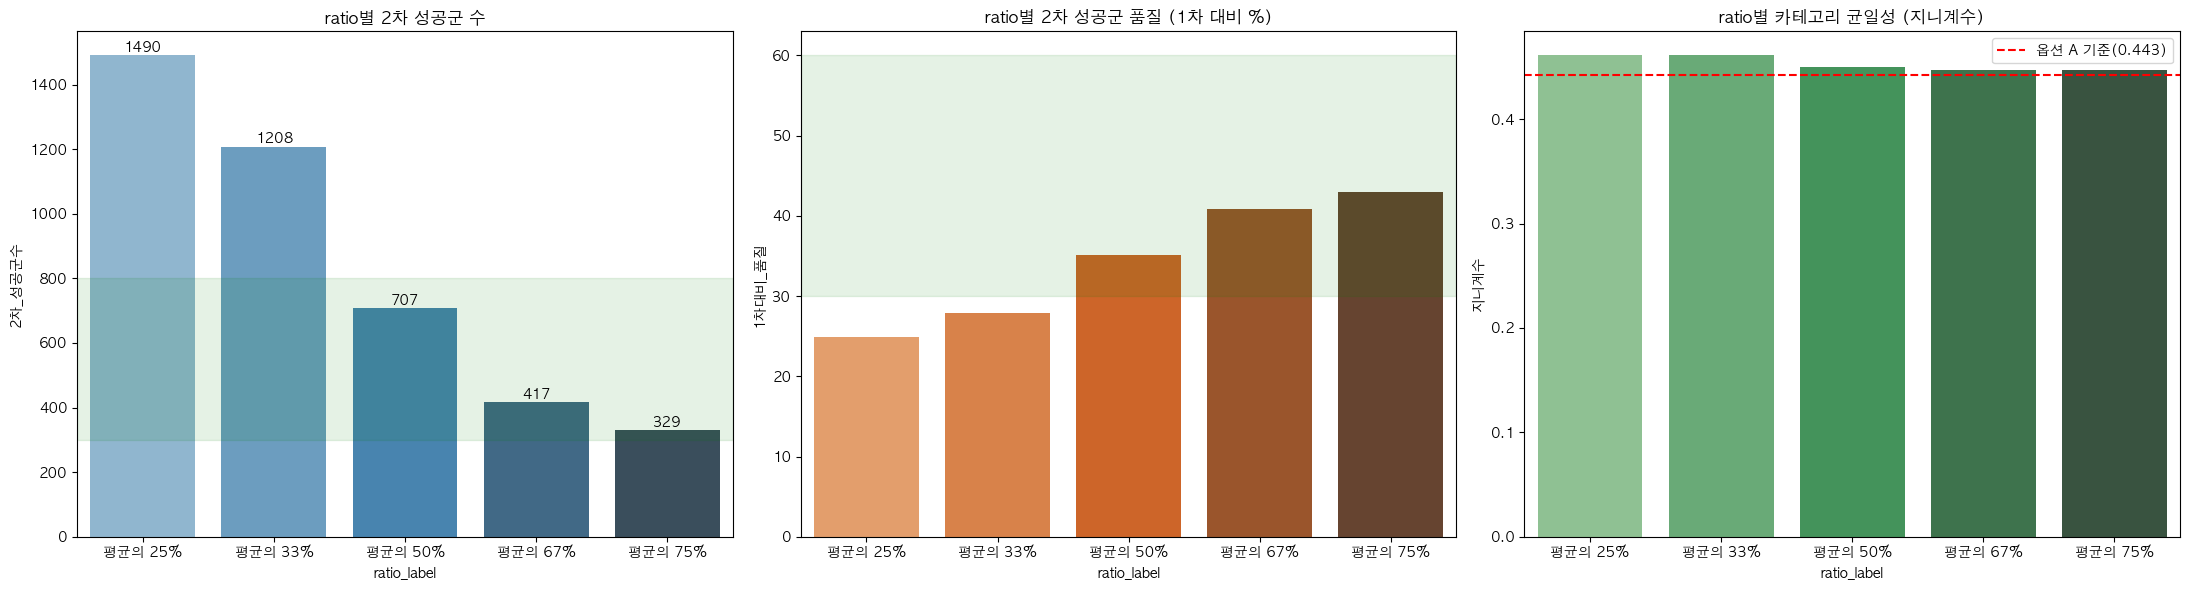

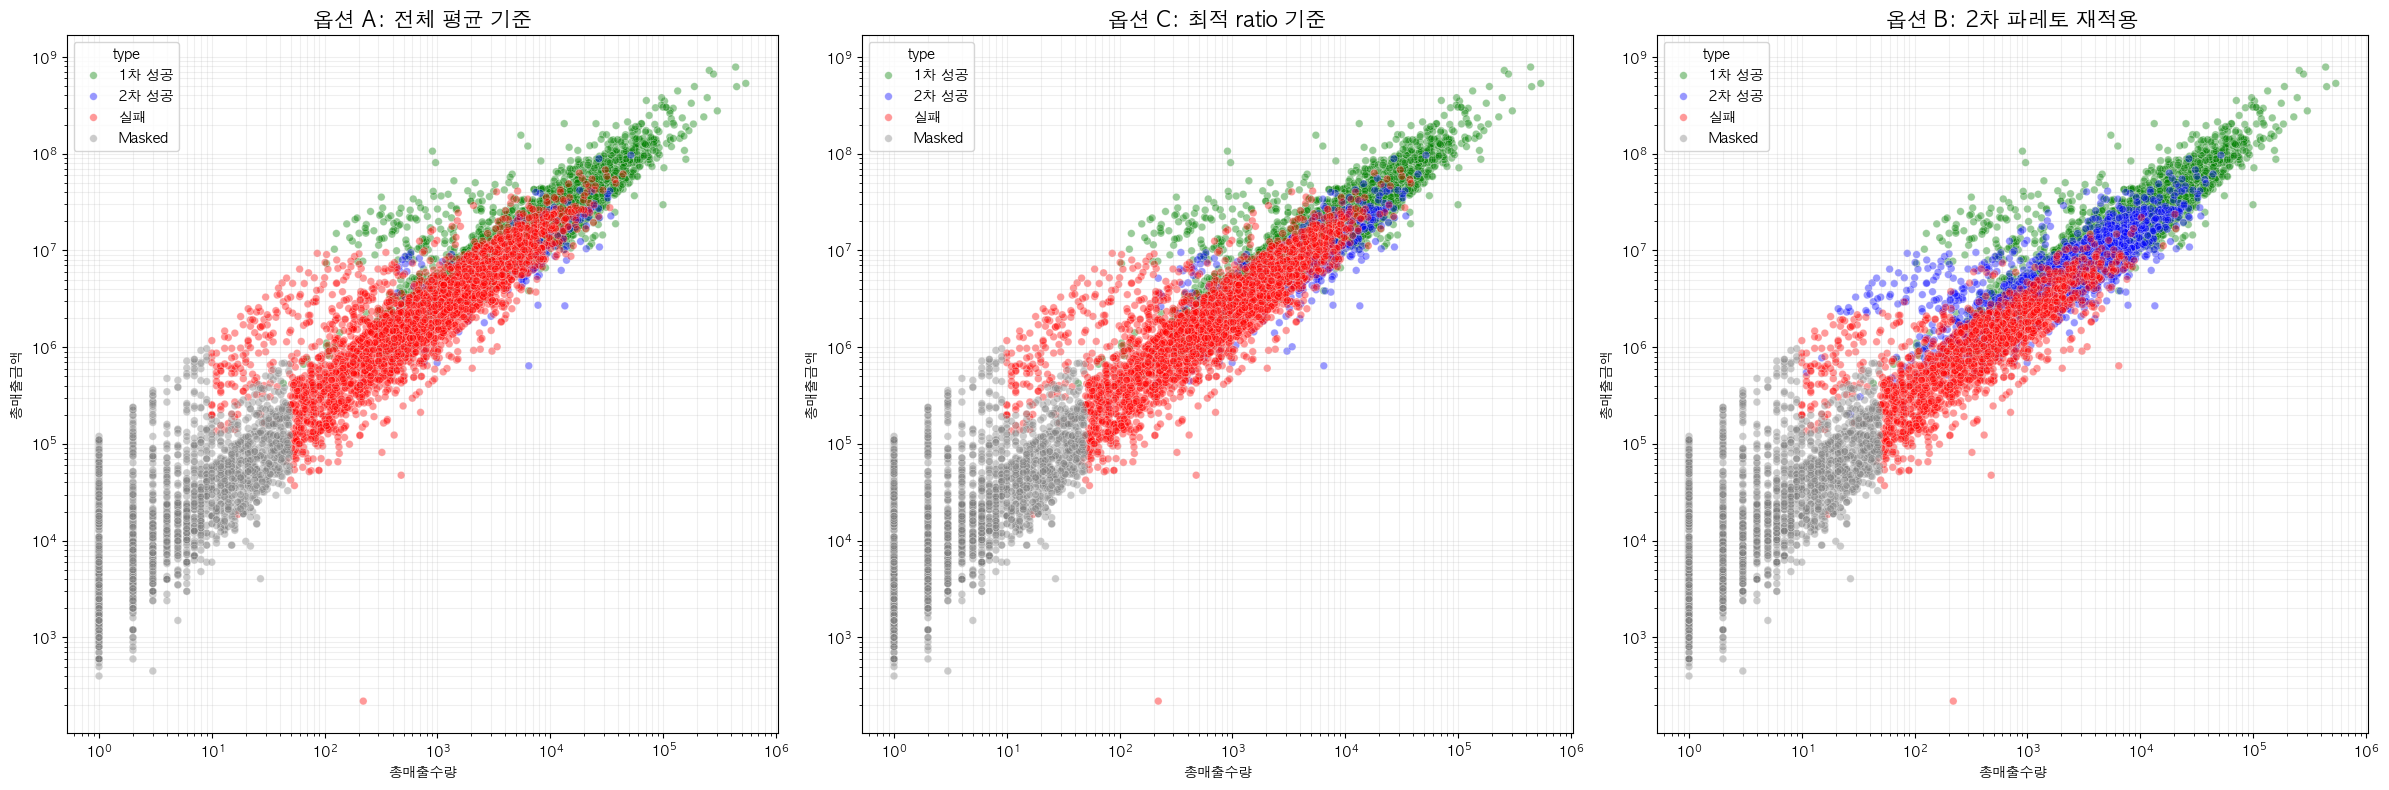

In [5]:
import os
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시 (시각화 관련)
warnings.filterwarnings("ignore")

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
DATA_DIR = "/Users/hajiyoon/workspace/data/processed"
POS_PATH = os.path.join(DATA_DIR, "pos_data_food_final_상품단위변환전.parquet")
B4_PATH = os.path.join(DATA_DIR, "B4_CLEAN_FOOD_ITEM.parquet")

# 확정된 기준값
MASKING_CATS     = ["쌀/잡곡", "시즌케익", "기타", "분말가루", "샐러드모닝랩", "쨈/꿀", "식빵"]
GROUP_A_CATS     = ["와인", "양주", "선물세트", "신선냉동"]
LOCAL_N          = 10
GLOBAL_N         = 50
PARETO_THRESHOLD = 0.80

# 옵션 C 검증할 X% 후보
OPTION_C_RATIOS  = [0.25, 0.33, 0.50, 0.67, 0.75]

def gini_coefficient(values):
    """지니계수 계산 (불평등도/균일성 측정)"""
    arr = np.sort(np.array(values, dtype=float))
    n = len(arr)
    if n == 0 or arr.sum() == 0:
        return np.nan
    cumsum = np.cumsum(arr)
    return (2 * np.sum(np.arange(1, n+1) * arr) - (n+1) * cumsum[-1]) / (n * cumsum[-1])

def create_simulation_data():
    """실제 파일이 없을 경우 시뮬레이션 데이터 생성"""
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR, exist_ok=True)
    
    print("! 데이터 파일이 없어 시뮬레이션 데이터를 생성합니다.")
    
    # B4 시뮬레이션
    categories = ["과자", "음료", "유제품", "라면", "빵", "와인", "양주", "선물세트", "신선냉동", "즉석식품"]
    b4_data = []
    for i in range(1, 3001):
        cat = np.random.choice(categories)
        b4_data.append({
            "상품코드": f"ITEM_{i:04d}",
            "중분류명": cat,
            "소분류명": f"{cat}_소",
            "상품명": f"{cat}_상품_{i}"
        })
    pl.from_dicts(b4_data).write_parquet(B4_PATH)

    # POS 시뮬레이션 (파레토 분포 유도)
    pos_data = []
    for i in range(1, 3001):
        item_id = f"ITEM_{i:04d}"
        qty = int(np.random.exponential(scale=300)) + 1
        amt = qty * np.random.randint(1000, 5000)
            
        pos_data.append({
            "상품코드": item_id,
            "매출수량": float(qty),
            "매출금액": float(amt)
        })
    pl.from_dicts(pos_data).write_parquet(POS_PATH)

def load_and_aggregate():
    """Polars Lazy Mode를 이용한 데이터 로딩 및 집계"""
    if not os.path.exists(POS_PATH) or not os.path.exists(B4_PATH):
        create_simulation_data()

    print("[1/8] 데이터 로딩 및 집계 중 (Polars Lazy)...")
    collected = (
        pl.scan_parquet(POS_PATH)
        .filter(
            (pl.col("매출수량") > 0) &
            (pl.col("매출금액") > 0)
        )
        .join(
            pl.scan_parquet(B4_PATH)
              .select(["상품코드", "중분류명", "소분류명", "상품명"]),
            on="상품코드", how="inner"
        )
        .filter(~pl.col("중분류명").is_in(MASKING_CATS))
        .group_by(["상품코드", "중분류명", "소분류명", "상품명"])
        .agg([
            pl.col("매출금액").sum().alias("총매출금액"),
            pl.col("매출수량").sum().alias("총매출수량")
        ])
        .collect()
    )
    return collected.to_pandas()

def prepare_data(df):
    """N 기준 필터 및 1차 파레토 적용"""
    print("[2/8] N 기준 필터 및 1차 파레토(80%) 적용 중...")
    
    n_threshold = df['중분류명'].apply(
        lambda c: LOCAL_N if c in GROUP_A_CATS else GLOBAL_N
    )
    mask_n_pass = df['총매출수량'] >= n_threshold
    df_masked = df[~mask_n_pass].copy()
    
    df_valid = df[mask_n_pass].copy()
    
    def apply_pareto_80(df_in):
        df_out = df_in.copy()
        df_out['pareto_1st'] = 0
        for cat, group in df_out.groupby('중분류명'):
            group_sorted = group.sort_values('총매출금액', ascending=False)
            total = group_sorted['총매출금액'].sum()
            if total == 0: continue
            cumsum = group_sorted['총매출금액'].cumsum()
            cum_ratio = cumsum / total
            success_idx = group_sorted[cum_ratio <= PARETO_THRESHOLD].index
            if len(success_idx) < len(group_sorted):
                next_idx = group_sorted.index[len(success_idx)]
                success_idx = success_idx.append(pd.Index([next_idx]))
            df_out.loc[success_idx, 'pareto_1st'] = 1
        return df_out

    df_valid = apply_pareto_80(df_valid)
    df_first = df_valid[df_valid['pareto_1st'] == 1].copy()
    df_remain = df_valid[df_valid['pareto_1st'] == 0].copy()
    
    return df_valid, df_masked, df_first, df_remain

def option_a_mean_threshold(df_first, df_remain):
    """옵션 A: 카테고리 전체 평균 기준"""
    df_all = pd.concat([df_first, df_remain])
    cat_mean = df_all.groupby('중분류명')['총매출수량'].mean().reset_index().rename(columns={'총매출수량': '카테고리_평균판매량'})
    df_remain2 = df_remain.merge(cat_mean, on='중분류명', how='left')
    df_remain2['label_a'] = (df_remain2['총매출수량'] >= df_remain2['카테고리_평균판매량']).astype(int)
    return df_remain2

def option_b_pareto_reapply(df_remain):
    """옵션 B: 나머지 20% 구간 내 파레토 재적용"""
    df_remain2 = df_remain.copy()
    df_remain2['label_b'] = 0
    for cat, group in df_remain2.groupby('중분류명'):
        if len(group) == 0: continue
        group_sorted = group.sort_values('총매출금액', ascending=False)
        total = group_sorted['총매출금액'].sum()
        if total == 0: continue
        cumsum = group_sorted['총매출금액'].cumsum()
        cum_ratio = cumsum / total
        success_idx = group_sorted[cum_ratio <= PARETO_THRESHOLD].index
        if len(success_idx) < len(group_sorted):
            next_idx = group_sorted.index[len(success_idx)]
            success_idx = success_idx.append(pd.Index([next_idx]))
        df_remain2.loc[success_idx, 'label_b'] = 1
    return df_remain2

def option_c_partial_mean(df_first, df_remain, ratio):
    """옵션 C: 전체 평균의 ratio% 이상 → 2차 성공군"""
    df_all = pd.concat([df_first, df_remain])
    cat_mean = df_all.groupby('중분류명')['총매출수량'].mean().reset_index().rename(columns={'총매출수량': '카테고리_평균판매량'})
    df_remain2 = df_remain.merge(cat_mean, on='중분류명', how='left')
    threshold = df_remain2['카테고리_평균판매량'] * ratio
    df_remain2['label_c'] = (df_remain2['총매출수량'] >= threshold).astype(int)
    df_remain2['label_reason_c'] = df_remain2['label_c'].map({
        1: f'나머지20%_평균{int(ratio*100)}%초과(2차성공)',
        0: f'나머지20%_평균{int(ratio*100)}%미달(실패)'
    })
    return df_remain2

def find_optimal_ratio(df_first, df_remain, ratios):
    """각 ratio별로 검증을 수행하고 최적 ratio 선택을 위한 결과 반환"""
    print("[3/8] 옵션 C: ratio별 검증 진행 중...")
    results = []
    mean_1st = df_first['총매출수량'].mean()

    # 옵션 A의 지니계수 계산 (비교용)
    df_a = option_a_mean_threshold(df_first, df_remain)
    combined_a = pd.concat([df_first.assign(label=1), df_a.rename(columns={'label_a': 'label'})])
    gini_a = gini_coefficient(combined_a[combined_a['label']==1].groupby('중분류명').size().values)

    for ratio in ratios:
        df_c = option_c_partial_mean(df_first, df_remain, ratio)
        cnt_2nd = (df_c['label_c'] == 1).sum()
        mean_2nd = df_c[df_c['label_c']==1]['총매출수량'].mean() if cnt_2nd > 0 else 0
        
        combined = pd.concat([df_first.assign(label=1), df_c.rename(columns={'label_c': 'label'})])
        cat_cnt = combined[combined['label']==1].groupby('중분류명').size()
        gini = gini_coefficient(cat_cnt.values)

        cond1 = 300 <= cnt_2nd <= 800
        cond2 = 0.30 <= (mean_2nd / mean_1st) <= 0.60
        cond3 = gini <= (gini_a + 0.01)

        results.append({
            'ratio': ratio,
            'ratio_label': f"평균의 {int(ratio*100)}%",
            '2차_성공군수': cnt_2nd,
            '2차_평균판매량': round(mean_2nd),
            '1차대비_품질': round(mean_2nd / mean_1st * 100, 1) if mean_1st > 0 else 0,
            '지니계수': round(gini, 3),
            '조건1_수': cond1,
            '조건2_품질': cond2,
            '조건3_균일': cond3,
            '전체조건충족': cond1 and cond2 and cond3
        })
    return pd.DataFrame(results), gini_a

def select_optimal_ratio(ratio_results):
    """조건을 모두 만족하는 ratio 중 가장 균형 잡힌 것 선택"""
    qualified = ratio_results[ratio_results['전체조건충족'] == True]
    if not qualified.empty:
        qualified['dist'] = (qualified['2차_성공군수'] - 550).abs()
        return qualified.sort_values('dist').iloc[0]['ratio']
    else:
        return ratio_results.sort_values('지니계수').iloc[0]['ratio']

def visualize_ratio_comparison(results, gini_a):
    """Figure 1: ratio별 검증 결과 비교"""
    print("[7/8] 시각화 생성 중 (Ratio 비교)...")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    sns.barplot(data=results, x='ratio_label', y='2차_성공군수', ax=axes[0], palette='Blues_d')
    axes[0].axhspan(300, 800, color='green', alpha=0.1, label='목표 범위')
    axes[0].set_title("ratio별 2차 성공군 수")
    for i, v in enumerate(results['2차_성공군수']):
        axes[0].text(i, v + 10, f"{v}", ha='center', fontweight='bold')

    sns.barplot(data=results, x='ratio_label', y='1차대비_품질', ax=axes[1], palette='Oranges_d')
    axes[1].axhspan(30, 60, color='green', alpha=0.1, label='목표 범위')
    axes[1].set_title("ratio별 2차 성공군 품질 (1차 대비 %)")

    sns.barplot(data=results, x='ratio_label', y='지니계수', ax=axes[2], palette='Greens_d')
    axes[2].axhline(y=gini_a, color='red', linestyle='--', label=f'옵션 A 기준({gini_a:.3f})')
    axes[2].set_title("ratio별 카테고리 균일성 (지니계수)")
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig("option_c_ratio_comparison.png", dpi=300)

def visualize_abc_scatter(df_first, df_a, df_c, df_b, df_masked):
    """Figure 2: 옵션 A, C, B 산점도 비교"""
    print("[7/8] 시각화 생성 중 (ABC 비교 산점도)...")
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    titles = ["옵션 A: 전체 평균 기준", "옵션 C: 최적 ratio 기준", "옵션 B: 2차 파레토 재적용"]
    dfs = [df_a.rename(columns={'label_a': 'label'}), 
           df_c.rename(columns={'label_c': 'label'}), 
           df_b.rename(columns={'label_b': 'label'})]

    for i, (df_res, title) in enumerate(zip(dfs, titles)):
        df_viz = pd.concat([
            df_first.assign(type='1차 성공'),
            df_res[df_res['label']==1].assign(type='2차 성공'),
            df_res[df_res['label']==0].assign(type='실패'),
            df_masked.assign(type='Masked')
        ])
        
        sns.scatterplot(data=df_viz, x='총매출수량', y='총매출금액', hue='type', 
                        palette={'1차 성공':'green', '2차 성공':'blue', '실패':'red', 'Masked':'grey'},
                        alpha=0.4, ax=axes[i], s=30)
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].set_title(title, fontsize=15)
        axes[i].grid(True, which="both", ls="-", alpha=0.2)

    plt.tight_layout()
    plt.savefig("option_abc_scatter_comparison.png", dpi=300)

def print_final_decision(results, df_first, df_a, df_c, df_b, gini_a, opt_ratio_val):
    """최종 판정 및 비교 결과 출력"""
    opt_ratio = results[results['ratio'] == opt_ratio_val].iloc[0]
    
    a_cnt = (df_a['label_a'] == 1).sum()
    a_quality = round(df_a[df_a['label_a']==1]['총매출수량'].mean() / df_first['총매출수량'].mean() * 100, 1)
    
    b_cnt = (df_b['label_b'] == 1).sum()
    b_quality = round(df_b[df_b['label_b']==1]['총매출수량'].mean() / df_first['총매출수량'].mean() * 100, 1)
    
    combined_b = pd.concat([df_first.assign(label=1), df_b.rename(columns={'label_b': 'label'})])
    gini_b = gini_coefficient(combined_b[combined_b['label']==1].groupby('중분류명').size().values)

    print("\n" + "="*60)
    print(" [옵션 C 검증 결과]")
    print("="*60)
    print("[ratio별 검증 결과]\n")
    print(f"{'ratio':<12} | {'2차성공군수':<8} | {'1차대비품질':<8} | {'지니계수':<8} | {'조건충족'}")
    print("-" * 65)
    for _, row in results.iterrows():
        check = "✅" if row['전체조건충족'] else "❌"
        print(f"{row['ratio_label']:<12} | {row['2차_성공군수']:>7}개 | {row['1차대비_품질']:>9.1f}% | {row['지니계수']:>8.3f} | {check}")

    print("\n[3가지 옵션 최종 비교]")
    print(f"{'구분':<12} | {'2차성공군수':<8} | {'1차대비품질':<8} | {'지니계수':<8}")
    print("-" * 55)
    print(f"{'옵션 A':<12} | {a_cnt:>7}개 | {a_quality:>9.1f}% | {gini_a:>8.3f}")
    print(f"{'옵션 C(최적)':<12} | {opt_ratio['2차_성공군수']:>7}개 | {opt_ratio['1차대비_품질']:>9.1f}% | {opt_ratio['지니계수']:>8.3f}")
    print(f"{'옵션 B':<12} | {b_cnt:>7}개 | {b_quality:>9.1f}% | {gini_b:>8.3f}")

    print("\n[최종 판정]")
    print(f"  채택 옵션: C ({opt_ratio['ratio_label']})")
    print(f"  2차 성공군 수:  {opt_ratio['2차_성공군수']}개")
    print(f"  1차 대비 품질:  {opt_ratio['1차대비_품질']}%")
    print(f"  지니계수:       {opt_ratio['지니계수']}")
    
    print("\n  근거:")
    print(f"  - 수량: 300~800개 범위 내 {'✅' if opt_ratio['조건1_수'] else '❌'}")
    print(f"  - 품질: 1차의 30~60% 수준 {'✅' if opt_ratio['조건2_품질'] else '❌'}")
    print(f"  - 균일성: 지니계수 {gini_a:.3f} 이하 {'✅' if opt_ratio['조건3_균일'] else '❌'}")
    print("="*60)

if __name__ == "__main__":
    df_raw = load_and_aggregate()
    df_v, df_m, df_f, df_r = prepare_data(df_raw)
    ratio_results, gini_a_val = find_optimal_ratio(df_f, df_r, OPTION_C_RATIOS)
    optimal_ratio_val = select_optimal_ratio(ratio_results)
    df_remain_c = option_c_partial_mean(df_f, df_r, optimal_ratio_val)
    df_remain_a = option_a_mean_threshold(df_f, df_r)
    df_remain_b = option_b_pareto_reapply(df_r)
    
    visualize_ratio_comparison(ratio_results, gini_a_val)
    visualize_abc_scatter(df_f, df_remain_a, df_remain_c, df_remain_b, df_m)
    print_final_decision(ratio_results, df_f, df_remain_a, df_remain_c, df_remain_b, gini_a_val, optimal_ratio_val)


In [6]:
import os
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ─────────────────────────────────────────────
# [경로 및 기준값]
# ─────────────────────────────────────────────
DATA_DIR         = "/Users/hajiyoon/workspace/data/processed"
POS_PATH         = os.path.join(DATA_DIR, "pos_data_food_final_상품단위변환전.parquet")
B4_PATH          = os.path.join(DATA_DIR, "B4_CLEAN_FOOD_ITEM.parquet")

MASKING_CATS     = ["쌀/잡곡", "시즌케익", "기타", "분말가루", "샐러드모닝랩", "쨈/꿀", "식빵"]
GROUP_A_CATS     = ["와인", "양주", "선물세트", "신선냉동"]
LOCAL_N          = 10
GLOBAL_N         = 50
PARETO_THRESHOLD = 0.80

# 중앙값 기준 ratio 후보
# 카테고리 중앙값의 몇 %를 기준으로 할 것인가
MEDIAN_RATIOS    = [0.50, 0.75, 1.00, 1.25, 1.50]


# ─────────────────────────────────────────────
# [지니계수]
# ─────────────────────────────────────────────
def gini_coefficient(values):
    arr = np.sort(np.array(values, dtype=float))
    n   = len(arr)
    if n == 0 or arr.sum() == 0:
        return np.nan
    cumsum = np.cumsum(arr)
    return (2 * np.sum(np.arange(1, n+1) * arr) - (n+1) * cumsum[-1]) / (n * cumsum[-1])


# ─────────────────────────────────────────────
# [시뮬레이션 데이터]
# ─────────────────────────────────────────────
def create_simulation_data():
    os.makedirs(DATA_DIR, exist_ok=True)
    print("! 데이터 파일이 없어 시뮬레이션 데이터를 생성합니다.")

    # 소수 독점 구조를 반영한 시뮬레이션
    # (소주처럼 1~2개 상품이 대부분 판매를 차지하는 구조 포함)
    categories = {
        "과자": (200, False),   # (SKU수, 독점구조여부)
        "음료": (150, False),
        "유제품": (100, False),
        "라면": (120, False),
        "빵": (80, False),
        "와인": (60, False),
        "양주": (50, False),
        "선물세트": (70, False),
        "신선냉동": (40, False),
        "소주": (80, True),    # 소수 독점 구조
        "맥주": (100, True),   # 소수 독점 구조
    }

    b4_data, pos_data = [], []
    item_counter = 1

    for cat, (n_sku, is_dominated) in categories.items():
        for i in range(n_sku):
            code = f"ITEM_{item_counter:04d}"
            b4_data.append({
                "상품코드": code,
                "중분류명": cat,
                "소분류명": f"{cat}_소",
                "상품명":   f"{cat}_상품_{i+1}"
            })

            # 소수 독점 구조: 상위 5%는 압도적으로 많이 팔림
            if is_dominated and i < max(1, int(n_sku * 0.05)):
                qty = int(np.random.uniform(50000, 100000))
            elif is_dominated:
                qty = int(np.random.exponential(scale=30)) + 1
            else:
                qty = int(np.random.exponential(scale=300)) + 1

            amt = qty * np.random.randint(1000, 5000)
            pos_data.append({
                "상품코드": code,
                "매출수량": float(qty),
                "매출금액": float(amt)
            })
            item_counter += 1

    pl.DataFrame(b4_data).write_parquet(B4_PATH)
    pl.DataFrame(pos_data).write_parquet(POS_PATH)


# ─────────────────────────────────────────────
# [Step 1] Polars Lazy 로딩 및 집계
# ─────────────────────────────────────────────
def load_and_aggregate():
    if not os.path.exists(POS_PATH) or not os.path.exists(B4_PATH):
        create_simulation_data()

    print("[1/7] 데이터 로딩 및 집계 중 (Polars Lazy)...")
    collected = (
        pl.scan_parquet(POS_PATH)
        .filter(
            (pl.col("매출수량") > 0) &
            (pl.col("매출금액") > 0)
        )
        .join(
            pl.scan_parquet(B4_PATH)
              .select(["상품코드", "중분류명", "소분류명", "상품명"]),
            on="상품코드", how="inner"
        )
        .filter(~pl.col("중분류명").is_in(MASKING_CATS))
        .group_by(["상품코드", "중분류명", "소분류명", "상품명"])
        .agg([
            pl.col("매출금액").sum().alias("총매출금액"),
            pl.col("매출수량").sum().alias("총매출수량")
        ])
        .collect()
    )
    return collected.to_pandas()


# ─────────────────────────────────────────────
# [Step 2] N 기준 필터 + 1차 파레토 적용
# ─────────────────────────────────────────────
def prepare_data(df):
    print("[2/7] N 기준 필터 및 1차 파레토(80%) 적용 중...")

    n_threshold  = df['중분류명'].apply(lambda c: LOCAL_N if c in GROUP_A_CATS else GLOBAL_N)
    mask_n_pass  = df['총매출수량'] >= n_threshold
    df_masked    = df[~mask_n_pass].copy()
    df_valid     = df[mask_n_pass].copy()

    def apply_pareto_80(df_in):
        df_out = df_in.copy()
        df_out['pareto_1st'] = 0
        for cat, group in df_out.groupby('중분류명'):
            gs    = group.sort_values('총매출금액', ascending=False)
            total = gs['총매출금액'].sum()
            if total == 0: continue
            cum   = gs['총매출금액'].cumsum() / total
            idx   = gs[cum <= PARETO_THRESHOLD].index
            if len(idx) < len(gs):
                idx = idx.append(pd.Index([gs.index[len(idx)]]))
            df_out.loc[idx, 'pareto_1st'] = 1
        return df_out

    df_valid  = apply_pareto_80(df_valid)
    df_first  = df_valid[df_valid['pareto_1st'] == 1].copy()
    df_remain = df_valid[df_valid['pareto_1st'] == 0].copy()

    print(f"    1차 성공군: {len(df_first):,}개 / 나머지: {len(df_remain):,}개 / Masked: {len(df_masked):,}개")
    return df_valid, df_masked, df_first, df_remain


# ─────────────────────────────────────────────
# [핵심 변경] 중앙값 기반 2차 성공군 옵션들
# ─────────────────────────────────────────────

def option_mean(df_first, df_remain):
    """기존 옵션 A: 카테고리 전체 평균 이상"""
    df_all   = pd.concat([df_first, df_remain])
    cat_stat = (
        df_all.groupby('중분류명')['총매출수량']
        .mean()
        .reset_index()
        .rename(columns={'총매출수량': '기준값'})
    )
    df_r2             = df_remain.merge(cat_stat, on='중분류명', how='left')
    df_r2['label']    = (df_r2['총매출수량'] >= df_r2['기준값']).astype(int)
    df_r2['방법']     = '평균 기준'
    return df_r2


def option_median(df_first, df_remain):
    """
    신규 옵션: 카테고리 전체 중앙값 이상
    → 소수 메가히트 상품이 기준을 왜곡하는 문제 해결
    → 중앙값 = 실제 분포의 중간값 → 더 공정한 기준
    """
    df_all   = pd.concat([df_first, df_remain])
    cat_stat = (
        df_all.groupby('중분류명')['총매출수량']
        .median()
        .reset_index()
        .rename(columns={'총매출수량': '기준값'})
    )
    df_r2             = df_remain.merge(cat_stat, on='중분류명', how='left')
    df_r2['label']    = (df_r2['총매출수량'] >= df_r2['기준값']).astype(int)
    df_r2['방법']     = '중앙값 기준'
    return df_r2


def option_median_ratio(df_first, df_remain, ratio):
    """
    중앙값의 ratio% 이상 기준
    → ratio < 1.0: 중앙값보다 완화된 기준 (더 많은 성공군)
    → ratio > 1.0: 중앙값보다 엄격한 기준 (더 적은 성공군)
    """
    df_all   = pd.concat([df_first, df_remain])
    cat_stat = (
        df_all.groupby('중분류명')['총매출수량']
        .median()
        .reset_index()
        .rename(columns={'총매출수량': '중앙값'})
    )
    df_r2             = df_remain.merge(cat_stat, on='중분류명', how='left')
    df_r2['기준값']   = df_r2['중앙값'] * ratio
    df_r2['label']    = (df_r2['총매출수량'] >= df_r2['기준값']).astype(int)
    df_r2['방법']     = f'중앙값×{ratio}'
    return df_r2


# ─────────────────────────────────────────────
# [Step 3] 평균 vs 중앙값 비교 분석
# ─────────────────────────────────────────────
def compare_mean_vs_median(df_first, df_remain):
    print("[3/7] 평균 vs 중앙값 기준 비교 중...")

    df_mean   = option_mean(df_first, df_remain)
    df_median = option_median(df_first, df_remain)
    mean_1st  = df_first['총매출수량'].mean()

    results = []
    for df_r, label in [(df_mean, '평균 기준'), (df_median, '중앙값 기준')]:
        cnt     = (df_r['label'] == 1).sum()
        quality = df_r[df_r['label']==1]['총매출수량'].mean() / mean_1st * 100 if cnt > 0 else 0
        combined = pd.concat([df_first.assign(label=1), df_r])
        gini     = gini_coefficient(
            combined[combined['label']==1].groupby('중분류명').size().values
        )
        results.append({
            '기준':        label,
            '2차_성공군수': cnt,
            '1차대비_품질': round(quality, 1),
            '지니계수':    round(gini, 3)
        })

    return pd.DataFrame(results), df_mean, df_median


# ─────────────────────────────────────────────
# [Step 4] 중앙값 ratio별 검증
# ─────────────────────────────────────────────
def validate_median_ratios(df_first, df_remain):
    print("[4/7] 중앙값 ratio별 검증 중...")

    mean_1st = df_first['총매출수량'].mean()
    results  = []

    for ratio in MEDIAN_RATIOS:
        df_r  = option_median_ratio(df_first, df_remain, ratio)
        cnt   = (df_r['label'] == 1).sum()
        qual  = df_r[df_r['label']==1]['총매출수량'].mean() / mean_1st * 100 if cnt > 0 else 0
        comb  = pd.concat([df_first.assign(label=1), df_r])
        gini  = gini_coefficient(comb[comb['label']==1].groupby('중분류명').size().values)

        results.append({
            'ratio':        ratio,
            'ratio_label':  f"중앙값×{ratio}",
            '2차_성공군수':  cnt,
            '1차대비_품질':  round(qual, 1),
            '지니계수':      round(gini, 3),
            '조건1':         300 <= cnt <= 800,
            '조건2':         0.30 <= qual/100 <= 0.60,
        })

    return pd.DataFrame(results)


# ─────────────────────────────────────────────
# [Step 5] 중앙값 vs 평균 왜곡 비교 시각화
# (소수 독점 구조 카테고리 집중 분석)
# ─────────────────────────────────────────────
def visualize_distortion(df_first, df_remain):
    print("[5/7] 중앙값 vs 평균 왜곡 비교 시각화 중...")

    df_all   = pd.concat([df_first, df_remain])
    cat_stat = (
        df_all.groupby('중분류명')
        .agg(
            평균=('총매출수량', 'mean'),
            중앙값=('총매출수량', 'median'),
            SKU수=('상품코드', 'count')
        )
        .reset_index()
    )
    cat_stat['평균_중앙값_비율'] = cat_stat['평균'] / cat_stat['중앙값']
    cat_stat = cat_stat.sort_values('평균_중앙값_비율', ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    # 차트 1: 카테고리별 평균/중앙값 비율 (높을수록 소수 독점 구조)
    top20 = cat_stat.head(20)
    axes[0].barh(top20['중분류명'], top20['평균_중앙값_비율'],
                 color=['tomato' if v > 3 else 'steelblue' for v in top20['평균_중앙값_비율']])
    axes[0].axvline(3, color='red', linestyle='--', alpha=0.7, label='3배 기준선')
    axes[0].axvline(1, color='gray', linestyle='--', alpha=0.5, label='1배 (평균=중앙값)')
    axes[0].set_title("카테고리별 평균/중앙값 비율\n(높을수록 소수 독점 구조)", fontsize=12)
    axes[0].set_xlabel("평균 ÷ 중앙값")
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', alpha=0.3)

    # 차트 2: 평균 vs 중앙값 산점도 (카테고리별)
    axes[1].scatter(cat_stat['중앙값'], cat_stat['평균'],
                    c=cat_stat['평균_중앙값_비율'], cmap='RdYlGn_r',
                    s=cat_stat['SKU수'] * 0.5, alpha=0.7, edgecolors='black', linewidth=0.5)
    max_val = max(cat_stat['평균'].max(), cat_stat['중앙값'].max())
    axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='평균=중앙값')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel("중앙값 (Log Scale)")
    axes[1].set_ylabel("평균 (Log Scale)")
    axes[1].set_title("카테고리별 평균 vs 중앙값\n(점 크기 = SKU 수)", fontsize=12)
    axes[1].legend(fontsize=9)

    # 차트 3: 평균/중앙값 비율 분포 히스토그램
    axes[2].hist(cat_stat['평균_중앙값_비율'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[2].axvline(cat_stat['평균_중앙값_비율'].mean(), color='red', linestyle='--',
                    label=f"평균: {cat_stat['평균_중앙값_비율'].mean():.1f}배")
    axes[2].axvline(3, color='orange', linestyle='--', label='3배 기준선')
    axes[2].set_xlabel("평균 ÷ 중앙값 비율")
    axes[2].set_ylabel("카테고리 수")
    axes[2].set_title("평균/중앙값 비율 분포\n(소수 독점 구조 카테고리 탐지)", fontsize=12)
    axes[2].legend(fontsize=9)
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig("median_vs_mean_distortion.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("    저장 완료: median_vs_mean_distortion.png")

    return cat_stat


# ─────────────────────────────────────────────
# [Step 6] 검증 결과 시각화
# ─────────────────────────────────────────────
def visualize_validation(compare_df, ratio_df, df_first, df_mean, df_median):
    print("[6/7] 검증 결과 시각화 중...")

    fig, axes = plt.subplots(2, 3, figsize=(22, 14))

    # ── 상단: 평균 vs 중앙값 직접 비교 ──

    # 차트 1: 2차 성공군 수 비교
    colors = ['steelblue', 'tomato']
    bars   = axes[0, 0].bar(compare_df['기준'], compare_df['2차_성공군수'], color=colors, edgecolor='black', width=0.5)
    for bar, v in zip(bars, compare_df['2차_성공군수']):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                        f"{v:,}개", ha='center', fontweight='bold', fontsize=12)
    axes[0, 0].set_title("평균 vs 중앙값 기준\n2차 성공군 수 비교", fontsize=12)
    axes[0, 0].set_ylabel("2차 성공군 수")
    axes[0, 0].grid(axis='y', alpha=0.3)

    # 차트 2: 품질 비교
    bars = axes[0, 1].bar(compare_df['기준'], compare_df['1차대비_품질'], color=colors, edgecolor='black', width=0.5)
    for bar, v in zip(bars, compare_df['1차대비_품질']):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)
    axes[0, 1].axhspan(30, 60, color='green', alpha=0.1, label='목표 범위(30~60%)')
    axes[0, 1].set_title("평균 vs 중앙값 기준\n2차 성공군 품질 (1차 대비 %)", fontsize=12)
    axes[0, 1].set_ylabel("1차 대비 품질 (%)")
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].grid(axis='y', alpha=0.3)

    # 차트 3: 지니계수 비교
    bars = axes[0, 2].bar(compare_df['기준'], compare_df['지니계수'], color=colors, edgecolor='black', width=0.5)
    for bar, v in zip(bars, compare_df['지니계수']):
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                        f"{v:.3f}", ha='center', fontweight='bold', fontsize=12)
    axes[0, 2].set_title("평균 vs 중앙값 기준\n지니계수 (낮을수록 균일)", fontsize=12)
    axes[0, 2].set_ylabel("지니계수")
    axes[0, 2].grid(axis='y', alpha=0.3)

    # ── 하단: 중앙값 ratio별 비교 ──

    # 차트 4: ratio별 성공군 수
    bar_colors = ['green' if (r['조건1'] and r['조건2']) else 'lightcoral' for _, r in ratio_df.iterrows()]
    bars = axes[1, 0].bar(ratio_df['ratio_label'], ratio_df['2차_성공군수'], color=bar_colors, edgecolor='black')
    axes[1, 0].axhspan(300, 800, color='green', alpha=0.1, label='목표 범위(300~800개)')
    for bar, v in zip(bars, ratio_df['2차_성공군수']):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                        f"{v:,}", ha='center', fontsize=10, fontweight='bold')
    axes[1, 0].set_title("중앙값 ratio별\n2차 성공군 수", fontsize=12)
    axes[1, 0].set_ylabel("2차 성공군 수")
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].tick_params(axis='x', rotation=20)
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 차트 5: ratio별 품질
    axes[1, 1].bar(ratio_df['ratio_label'], ratio_df['1차대비_품질'], color=bar_colors, edgecolor='black')
    axes[1, 1].axhspan(30, 60, color='green', alpha=0.1, label='목표 범위(30~60%)')
    axes[1, 1].set_title("중앙값 ratio별\n2차 성공군 품질 (1차 대비 %)", fontsize=12)
    axes[1, 1].set_ylabel("1차 대비 품질 (%)")
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].tick_params(axis='x', rotation=20)
    axes[1, 1].grid(axis='y', alpha=0.3)

    # 차트 6: ratio별 지니계수
    axes[1, 2].bar(ratio_df['ratio_label'], ratio_df['지니계수'], color=bar_colors, edgecolor='black')
    axes[1, 2].set_title("중앙값 ratio별\n지니계수 (낮을수록 균일)", fontsize=12)
    axes[1, 2].set_ylabel("지니계수")
    axes[1, 2].tick_params(axis='x', rotation=20)
    axes[1, 2].grid(axis='y', alpha=0.3)

    plt.suptitle("중앙값 기준 2차 성공군 검증 결과", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig("median_validation_result.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("    저장 완료: median_validation_result.png")


# ─────────────────────────────────────────────
# [Step 7] 산점도: 평균 vs 중앙값 성공군 비교
# ─────────────────────────────────────────────
def visualize_scatter_comparison(df_first, df_mean, df_median, df_masked):
    print("[7/7] 산점도 비교 시각화 중...")

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for ax, df_r, title in zip(
        axes,
        [df_mean, df_median],
        ["기존 옵션 A: 카테고리 전체 평균 기준", "신규 옵션: 카테고리 전체 중앙값 기준"]
    ):
        df_viz = pd.concat([
            df_first.assign(type='1차 성공'),
            df_r[df_r['label'] == 1].assign(type='2차 성공'),
            df_r[df_r['label'] == 0].assign(type='실패'),
            df_masked.assign(type='Masked')
        ])

        palette = {'1차 성공': 'green', '2차 성공': 'blue', '실패': 'salmon', 'Masked': 'lightgray'}
        order   = ['Masked', '실패', '2차 성공', '1차 성공']

        for t in order:
            sub = df_viz[df_viz['type'] == t]
            ax.scatter(sub['총매출수량'], sub['총매출금액'],
                       c=palette[t], alpha=0.4, s=20, label=t)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("총매출수량 (Log Scale)")
        ax.set_ylabel("총매출금액 (Log Scale)")
        ax.legend(fontsize=10)
        ax.grid(True, which='both', alpha=0.2)

        cnt = (df_r['label'] == 1).sum()
        ax.text(0.02, 0.98, f"2차 성공군: {cnt:,}개",
                transform=ax.transAxes, fontsize=11,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle("평균 vs 중앙값 기준: 2차 성공군 분포 비교", fontsize=15, y=1.01)
    plt.tight_layout()
    plt.savefig("median_vs_mean_scatter.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("    저장 완료: median_vs_mean_scatter.png")


# ─────────────────────────────────────────────
# [콘솔 출력]
# ─────────────────────────────────────────────
def print_summary(compare_df, ratio_df, cat_stat, df_first):
    print("\n" + "=" * 65)
    print(" [중앙값 기준 2차 성공군 검증 결과]")
    print("=" * 65)

    # 소수 독점 구조 카테고리 탐지
    dominated = cat_stat[cat_stat['평균_중앙값_비율'] > 3]['중분류명'].tolist()
    print(f"\n[소수 독점 구조 탐지] 평균/중앙값 비율 > 3배 카테고리: {len(dominated)}개")
    for cat in dominated:
        row = cat_stat[cat_stat['중분류명'] == cat].iloc[0]
        print(f"  {cat:<15}: 평균 {row['평균']:>8,.0f}개 / 중앙값 {row['중앙값']:>6,.0f}개 "
              f"(비율 {row['평균_중앙값_비율']:.1f}배)")

    # 평균 vs 중앙값 직접 비교
    print(f"\n[평균 vs 중앙값 기준 직접 비교]")
    print(f"{'기준':<12} | {'2차 성공군수':>10} | {'1차대비 품질':>12} | {'지니계수':>8}")
    print("-" * 55)
    for _, row in compare_df.iterrows():
        print(f"{row['기준']:<12} | {row['2차_성공군수']:>9,}개 | {row['1차대비_품질']:>11.1f}% | {row['지니계수']:>8.3f}")

    # 중앙값 ratio별 결과
    print(f"\n[중앙값 ratio별 검증 결과]")
    print(f"{'ratio':<12} | {'2차성공군수':>9} | {'1차대비품질':>11} | {'지니계수':>8} | {'조건충족'}")
    print("-" * 62)
    for _, row in ratio_df.iterrows():
        check = "✅" if (row['조건1'] and row['조건2']) else "❌"
        print(f"{row['ratio_label']:<12} | {row['2차_성공군수']:>8,}개 | "
              f"{row['1차대비_품질']:>10.1f}% | {row['지니계수']:>8.3f} | {check}")

    # 최종 권장
    qualified = ratio_df[ratio_df['조건1'] & ratio_df['조건2']]
    print(f"\n[최종 권장]")
    if not qualified.empty:
        best = qualified.sort_values('지니계수').iloc[0]
        print(f"  ▶ 최적 ratio: {best['ratio_label']}")
        print(f"     2차 성공군 수: {best['2차_성공군수']:,}개")
        print(f"     1차 대비 품질: {best['1차대비_품질']:.1f}%")
        print(f"     지니계수: {best['지니계수']:.3f}")
        print(f"\n  최종 성공군 합계:")
        print(f"     1차 성공군:  {len(df_first):,}개")
        print(f"     2차 성공군:  {best['2차_성공군수']:,}개")
        print(f"     합계:        {len(df_first) + best['2차_성공군수']:,}개")
    else:
        print("  ▶ 조건을 모두 만족하는 ratio가 없음 → 팀 논의 필요")

    print("=" * 65)


# ─────────────────────────────────────────────
# [실행]
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # 1. 데이터 로딩
    df_raw = load_and_aggregate()

    # 2. N 기준 + 1차 파레토 적용
    df_valid, df_masked, df_first, df_remain = prepare_data(df_raw)

    # 3. 평균 vs 중앙값 직접 비교
    compare_df, df_mean, df_median = compare_mean_vs_median(df_first, df_remain)

    # 4. 중앙값 ratio별 검증
    ratio_df = validate_median_ratios(df_first, df_remain)

    # 5. 왜곡 비교 시각화 (소수 독점 구조 분석)
    cat_stat = visualize_distortion(df_first, df_remain)

    # 6. 검증 결과 시각화
    visualize_validation(compare_df, ratio_df, df_first, df_mean, df_median)

    # 7. 산점도 비교
    visualize_scatter_comparison(df_first, df_mean, df_median, df_masked)

    # 8. 콘솔 출력
    print_summary(compare_df, ratio_df, cat_stat, df_first)

[1/7] 데이터 로딩 및 집계 중 (Polars Lazy)...
[2/7] N 기준 필터 및 1차 파레토(80%) 적용 중...
    1차 성공군: 1,922개 / 나머지: 3,567개 / Masked: 2,071개
[3/7] 평균 vs 중앙값 기준 비교 중...
[4/7] 중앙값 ratio별 검증 중...
[5/7] 중앙값 vs 평균 왜곡 비교 시각화 중...
    저장 완료: median_vs_mean_distortion.png
[6/7] 검증 결과 시각화 중...
    저장 완료: median_validation_result.png
[7/7] 산점도 비교 시각화 중...
    저장 완료: median_vs_mean_scatter.png

 [중앙값 기준 2차 성공군 검증 결과]

[소수 독점 구조 탐지] 평균/중앙값 비율 > 3배 카테고리: 22개
  선물세트           : 평균      467개 / 중앙값     25개 (비율 18.7배)
  소주             : 평균   26,195개 / 중앙값  1,993개 (비율 13.1배)
  세븐카페           : 평균    8,411개 / 중앙값    722개 (비율 11.7배)
  막걸리            : 평균   16,017개 / 중앙값  1,544개 (비율 10.4배)
  즉석간식           : 평균   10,710개 / 중앙값  1,257개 (비율 8.5배)
  수입맥주           : 평균    8,515개 / 중앙값  1,554개 (비율 5.5배)
  건해산물           : 평균    2,467개 / 중앙값    481개 (비율 5.1배)
  숙취해소제          : 평균   21,878개 / 중앙값  4,332개 (비율 5.1배)
  하이볼            : 평균    4,511개 / 중앙값    928개 (비율 4.9배)
  무알콜맥주          : 평균    5,176개 / 중앙값  1,084개 (비율 4.8배)
  얼음

(전체 중분류의 전체 판매량 합계/해당 중분류 sku 개수) = 이 중분류에서 상품 1개가 평균적으로 얼마나 팔렸는가.

그래서 이 평균을 각 중분류별로 기준점으로 두고, 2차 성공군은 이 평균을 넘었는가 못 넘었는가로 처리한다. 

In [7]:
import polars as pl

# 1차 성공군(파레토 80% 통과) 로드
# 앞서 생성한 df_first 사용

# 1차 성공군 중 N 기준 미달 상품 확인
n_threshold = df_first['중분류명'].apply(
    lambda c: LOCAL_N if c in GROUP_A_CATS else GLOBAL_N
)

# N 미달 상품 필터링
n_fail = df_first[df_first['총매출수량'] < n_threshold]

print(f"1차 성공군 전체: {len(df_first):,}개")
print(f"1차 성공군 중 N 미달: {len(n_fail):,}개")
print(f"비율: {len(n_fail)/len(df_first)*100:.1f}%")

if len(n_fail) > 0:
    print("\n[N 미달 상품 상세]")
    print(n_fail[['중분류명', '상품명', '총매출수량']].sort_values('총매출수량'))

1차 성공군 전체: 1,922개
1차 성공군 중 N 미달: 0개
비율: 0.0%


In [8]:
GROUP_A_CATS = ["와인", "양주", "선물세트", "신선냉동"]
LOCAL_N  = 10
GLOBAL_N = 50

# 나머지 20% 구간(df_remain)에서 N 기준별 미달 확인
df_remain['n_threshold'] = df_remain['중분류명'].apply(
    lambda c: LOCAL_N if c in GROUP_A_CATS else GLOBAL_N
)

# Group A / Group B 분리
group_a = df_remain[df_remain['중분류명'].isin(GROUP_A_CATS)]
group_b = df_remain[~df_remain['중분류명'].isin(GROUP_A_CATS)]

# N 미달 상품
a_fail = group_a[group_a['총매출수량'] < LOCAL_N]
b_fail = group_b[group_b['총매출수량'] < GLOBAL_N]

print(f"[Group A - Local N={LOCAL_N}]")
print(f"  전체: {len(group_a):,}개")
print(f"  N 미달: {len(a_fail):,}개 ({len(a_fail)/len(group_a)*100:.1f}%)")
print(f"  N 통과: {len(group_a)-len(a_fail):,}개")

print(f"\n[Group B - Global N={GLOBAL_N}]")
print(f"  전체: {len(group_b):,}개")
print(f"  N 미달: {len(b_fail):,}개 ({len(b_fail)/len(group_b)*100:.1f}%)")
print(f"  N 통과: {len(group_b)-len(b_fail):,}개")

print(f"\n[전체 합계]")
total_fail = len(a_fail) + len(b_fail)
print(f"  나머지 20% 전체: {len(df_remain):,}개")
print(f"  N 미달 (Masked): {total_fail:,}개 ({total_fail/len(df_remain)*100:.1f}%)")
print(f"  N 통과 (2차 후보): {len(df_remain)-total_fail:,}개")

[Group A - Local N=10]
  전체: 258개
  N 미달: 0개 (0.0%)
  N 통과: 258개

[Group B - Global N=50]
  전체: 3,309개
  N 미달: 0개 (0.0%)
  N 통과: 3,309개

[전체 합계]
  나머지 20% 전체: 3,567개
  N 미달 (Masked): 0개 (0.0%)
  N 통과 (2차 후보): 3,567개


In [19]:
import os
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ─────────────────────────────────────────────
# [경로 및 기준값]
# ─────────────────────────────────────────────
DATA_DIR    = "/Users/hajiyoon/workspace/data/processed"
POS_PATH    = os.path.join(DATA_DIR, "pos_data_food_final_상품단위변환전.parquet")
B4_PATH     = os.path.join(DATA_DIR, "B4_CLEAN_FOOD_ITEM.parquet")
OUTPUT_PATH = os.path.join(DATA_DIR, "LABELS_FINAL_v2.parquet")

MASKING_CATS  = ["쌀/잡곡", "시즌케익", "기타", "분말가루", "샐러드모닝랩",
                 "쨈/꿀", "식빵", "선물세트"]
GROUP_A_CATS  = ["와인", "양주", "신선냉동"]
LOCAL_N       = 10
GLOBAL_N      = 50
PARETO        = 0.80

LABEL_SUCCESS = 1
LABEL_FAIL    = 0
LABEL_MASKED  = -1


# ─────────────────────────────────────────────
# [시뮬레이션 데이터]
# ─────────────────────────────────────────────
def create_simulation_data():
    os.makedirs(DATA_DIR, exist_ok=True)
    print("! 데이터 파일이 없어 시뮬레이션 데이터를 생성합니다.")

    categories = (["과자", "음료", "유제품", "라면", "빵",
                   "와인", "양주", "신선냉동", "즉석식품"]
                  + MASKING_CATS)
    b4_data, pos_data = [], []

    for i in range(1, 5001):
        cat = np.random.choice(categories)
        b4_data.append({
            "상품코드": f"ITEM_{i:04d}",
            "중분류명": cat,
            "소분류명": f"{cat}_소",
            "상품명":   f"{cat}_상품_{i}"
        })
        qty = int(np.random.exponential(scale=200)) + 1
        amt = qty * np.random.randint(1000, 5000)
        pos_data.append({
            "상품코드": f"ITEM_{i:04d}",
            "매출수량": float(qty),
            "매출금액": float(amt)
        })

    pl.DataFrame(b4_data).write_parquet(B4_PATH)
    pl.DataFrame(pos_data).write_parquet(POS_PATH)


# ─────────────────────────────────────────────
# [Step 1] Polars Lazy 로딩 및 집계
# ─────────────────────────────────────────────
def load_and_aggregate():
    if not os.path.exists(POS_PATH) or not os.path.exists(B4_PATH):
        create_simulation_data()

    print("[1/6] 데이터 로딩 및 상품 단위 집계 중 (Polars Lazy)...")
    collected = (
        pl.scan_parquet(POS_PATH)
        .filter(
            (pl.col("매출수량") > 0) &
            (pl.col("매출금액") > 0)
        )
        .join(
            pl.scan_parquet(B4_PATH)
              .select(["상품코드", "중분류명", "소분류명", "상품명"]),
            on="상품코드", how="inner"
        )
        .group_by(["상품코드", "중분류명", "소분류명", "상품명"])
        .agg([
            pl.col("매출금액").sum().alias("총매출금액"),
            pl.col("매출수량").sum().alias("총매출수량")
        ])
        .collect()
    )
    df = collected.to_pandas()
    print(f"    집계 완료: {len(df):,}개 상품")
    return df


# ─────────────────────────────────────────────
# [Step 2] 라벨 생성
#
# STEP 1. Masking 카테고리 제외
# STEP 2. 전체 기준 파레토 80% → 1차 성공군
#         (N 미달 포함 전체 상품 기준으로 계산 → 매출 구조 왜곡 없음)
# STEP 3. 나머지 20%에서 N 미달 → Masked
#         (편향 학습 방지)
# STEP 4. N 통과 전체(1차+나머지) 평균 이상 → 2차 성공군
#         (N 통과 상품 기준 평균 → 왜곡 없는 기준선)
# STEP 5. 나머지 → 실패(0)
# ─────────────────────────────────────────────
def generate_labels(df):
    print("[2/6] 최종 라벨 생성 로직 적용 중 (5 STEP)...")
    df             = df.copy()
    df['label']        = LABEL_MASKED
    df['label_reason'] = ''
    df['success_type'] = 'None'

    # ── STEP 1. Masking 카테고리 제외 ──
    mask_cat = df['중분류명'].isin(MASKING_CATS)
    df.loc[mask_cat, 'label_reason'] = '구조적 SKU 부족 카테고리'
    print(f"    STEP 1 완료 | Masking 카테고리 제외: {mask_cat.sum():,}개")

    # 분석 대상: Masking 제외한 전체
    df_target = df[~mask_cat].copy()

    # ── STEP 2. 파레토 80% → 1차 성공군 ──
    # N 미달 포함 전체 기준으로 파레토 계산
    # → 카테고리 실제 매출 구조를 왜곡 없이 반영
    df_target['label']        = LABEL_FAIL
    df_target['label_reason'] = '파레토 미달'

    for cat, group in df_target.groupby('중분류명'):
        gs    = group.sort_values('총매출금액', ascending=False)
        total = gs['총매출금액'].sum()
        if total == 0:
            continue
        cum = gs['총매출금액'].cumsum() / total
        idx = gs[cum <= PARETO].index
        if len(idx) < len(gs):
            idx = idx.append(pd.Index([gs.index[len(idx)]]))
        df_target.loc[idx, 'label']        = LABEL_SUCCESS
        df_target.loc[idx, 'label_reason'] = '파레토 80% 1차 성공군'
        df_target.loc[idx, 'success_type'] = '1차 성공'

    cnt_1st = (df_target['label'] == LABEL_SUCCESS).sum()
    print(f"    STEP 2 완료 | 1차 성공군: {cnt_1st:,}개")

    # ── STEP 3. 나머지 20%에서 N 미달 → Masked ──
    # 파레토 탈락 상품 중 판매량 너무 적은 상품
    # → 실패(0) 아닌 Masked(-1) (편향 학습 방지)
    n_threshold = df_target['중분류명'].apply(
        lambda c: LOCAL_N if c in GROUP_A_CATS else GLOBAL_N
    )
    mask_remain_n_fail = (
        (df_target['label'] == LABEL_FAIL) &
        (df_target['총매출수량'] < n_threshold)
    )
    df_target.loc[mask_remain_n_fail, 'label'] = LABEL_MASKED
    df_target.loc[mask_remain_n_fail, 'label_reason'] = (
        df_target.loc[mask_remain_n_fail, '총매출수량']
        .apply(lambda x: f"N 기준 미달 ({int(x)} < ")
        + n_threshold[mask_remain_n_fail].astype(str) + ")"
    )
    df_target.loc[mask_remain_n_fail, 'success_type'] = 'None'

    cnt_n_masked = mask_remain_n_fail.sum()
    print(f"    STEP 3 완료 | 나머지 20% N 미달 Masked: {cnt_n_masked:,}개")

    # ── STEP 4. N 통과 상품 중 카테고리 평균 이상 → 2차 성공군 ──
    # 평균 계산 기준: N 통과 전체 상품 (1차 성공군 + 나머지 20% N 통과)
    # → N 미달 상품이 평균을 낮추는 왜곡 방지
    # → 1차 성공군 포함한 전체 N 통과 기준 → 더 엄격한 기준선
    df_n_pass = df_target[df_target['총매출수량'] >= n_threshold]

    cat_mean = (
        df_n_pass.groupby('중분류명')['총매출수량']
        .mean()
    )

    # 나머지 20% 중 N 통과 상품만 2차 후보
    df_remain_valid = df_target[df_target['label'] == LABEL_FAIL].copy()
    df_remain_valid['카테고리_평균'] = df_remain_valid['중분류명'].map(cat_mean)

    success_2nd_idx = df_remain_valid[
        df_remain_valid['총매출수량'] >= df_remain_valid['카테고리_평균']
    ].index

    df_target.loc[success_2nd_idx, 'label']        = LABEL_SUCCESS
    df_target.loc[success_2nd_idx, 'label_reason'] = '카테고리 평균 이상 2차 성공군'
    df_target.loc[success_2nd_idx, 'success_type'] = '2차 성공'

    cnt_2nd = len(success_2nd_idx)
    print(f"    STEP 4 완료 | 2차 성공군: {cnt_2nd:,}개")

    # ── STEP 5. 나머지 → 실패(0) ──
    mask_fail = df_target['label'] == LABEL_FAIL
    df_target.loc[mask_fail, 'label_reason'] = 'N 기준 통과 / 파레토 미달 / 카테고리 평균 미달'

    cnt_fail = mask_fail.sum()
    print(f"    STEP 5 완료 | 실패(0): {cnt_fail:,}개")

    # 전체 df에 결과 반영
    df.update(df_target[['label', 'label_reason', 'success_type']])

    return df


# ─────────────────────────────────────────────
# [Step 3] 검수
# ─────────────────────────────────────────────
def validate_labels(df):
    print("[3/6] 라벨 분포 검수 중...")
    issues  = []
    labeled = df[df['label'] != LABEL_MASKED]

    if len(labeled) == 0:
        return ["❌ ERROR: 학습 가능한 상품이 없습니다."]

    # 검수 1. 성공률 범위
    rate = (labeled['label'] == LABEL_SUCCESS).mean()
    if not (0.15 <= rate <= 0.40):
        issues.append(f"⚠️  성공률 {rate:.1%} → 정상 범위(15~40%) 벗어남")

    # 검수 2. 성공군 0개 카테고리
    cat_success = labeled.groupby('중분류명')['label'].sum()
    zero_cats   = cat_success[cat_success == 0].index.tolist()
    if zero_cats:
        issues.append(f"⚠️  성공군 0개 카테고리: {zero_cats}")

    # 검수 3. 성공군 3개 미만 카테고리 (0개 제외)
    low_cats = cat_success[
        (cat_success > 0) & (cat_success < 3)
    ].index.tolist()
    if low_cats:
        issues.append(f"⚠️  성공군 3개 미만 카테고리: {low_cats}")

    return issues


# ─────────────────────────────────────────────
# [Step 4] 시각화
# ─────────────────────────────────────────────
def visualize_labels(df):
    print("[4/6] 시각화 이미지 생성 중...")
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    # [차트 1] 전체 라벨 분포 파이차트
    order  = [LABEL_SUCCESS, LABEL_FAIL, LABEL_MASKED]
    names  = ['성공(1)', '실패(0)', 'Masked(-1)']
    colors = ['#2ecc71', '#e74c3c', '#95a5a6']
    values = [(df['label'] == l).sum() for l in order]

    axes[0].pie(
        values, labels=names, autopct='%1.1f%%',
        colors=colors, startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    axes[0].set_title("전체 상품 라벨 분포", fontsize=16, fontweight='bold')

    # [차트 2] 중분류별 성공군 수 (1차+2차 누적 막대, TOP 25)
    success_df = (
        df[df['label'] == LABEL_SUCCESS]
        .groupby(['중분류명', 'success_type'])
        .size()
        .unstack(fill_value=0)
    )
    if '1차 성공' not in success_df.columns:
        success_df['1차 성공'] = 0
    if '2차 성공' not in success_df.columns:
        success_df['2차 성공'] = 0

    success_df['total'] = success_df['1차 성공'] + success_df['2차 성공']
    success_df = success_df.sort_values('total', ascending=False).head(25)

    y_pos = np.arange(len(success_df))
    axes[1].barh(y_pos, success_df['1차 성공'],
                 color='#1b5e20', label='1차 성공 (파레토 80%)')
    axes[1].barh(y_pos, success_df['2차 성공'],
                 left=success_df['1차 성공'],
                 color='#4fc3f7', label='2차 성공 (카테고리 평균 이상)')

    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(success_df.index)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("성공 상품 수 (SKU)")
    axes[1].set_title("중분류별 성공군 발굴 현황 (TOP 25)", fontsize=16, fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].grid(axis='x', alpha=0.3)

    for i, cat in enumerate(success_df.index):
        if cat in GROUP_A_CATS:
            axes[1].get_yticklabels()[i].set_color('red')
            axes[1].get_yticklabels()[i].set_fontweight('bold')

    plt.tight_layout()
    plt.savefig("label_distribution_v2.png", dpi=150, bbox_inches='tight')
    plt.close()
    print("    저장 완료: label_distribution_v2.png")


# ─────────────────────────────────────────────
# [Step 5] 콘솔 출력
# ─────────────────────────────────────────────
def print_summary(df, issues):
    total       = len(df)
    success     = (df['label'] == LABEL_SUCCESS).sum()
    fail        = (df['label'] == LABEL_FAIL).sum()
    masked      = (df['label'] == LABEL_MASKED).sum()
    success_1st = (df['success_type'] == '1차 성공').sum()
    success_2nd = (df['success_type'] == '2차 성공').sum()
    n_masked    = df['label_reason'].str.contains('N 기준 미달', na=False).sum()
    cat_masked  = df['label_reason'].str.contains('구조적 SKU', na=False).sum()
    train_total = success + fail

    print("\n" + "=" * 60)
    print(" [최종 라벨 생성 결과 v2]")
    print("=" * 60)
    print(f"전체 상품 수:              {total:,}개")
    print(f"\n[라벨 분포]")
    print(f"  성공  (label=  1):       {success:,}개  ({success/total*100:.1f}%)")
    print(f"    └ 1차 성공군 (파레토):  {success_1st:,}개")
    print(f"    └ 2차 성공군 (평균):      {success_2nd:,}개")
    print(f"  실패  (label=  0):       {fail:,}개  ({fail/total*100:.1f}%)")
    print(f"  Masked(label= -1):       {masked:,}개  ({masked/total*100:.1f}%)")
    print(f"    └ N 기준 미달:          {n_masked:,}개")
    print(f"    └ Masking 카테고리:       {cat_masked:,}개")

    if train_total > 0:
        print(f"\n[학습 가능 기준 성공률]: {success/train_total*100:.1f}%")
        print(f"  (성공 / (성공 + 실패))")

    print(f"\n[적용된 순서]")
    print(f"  STEP 1. Masking 카테고리 제외 ({cat_masked:,}개)")
    print(f"  STEP 2. 전체 기준 파레토 80% → 1차 성공군 ({success_1st:,}개)")
    print(f"  STEP 3. 나머지 20%에서 N 미달 → Masked ({n_masked:,}개)")
    print(f"  STEP 4. N통과 전체 평균 이상 → 2차 성공군 ({success_2nd:,}개)")
    print(f"  STEP 5. 나머지 → 실패 ({fail:,}개)")

    print(f"\n[검수 결과]")
    if not issues:
        print("이상 없음 ✅")
    else:
        for issue in issues:
            print(issue)

    print(f"\n저장 완료: {os.path.basename(OUTPUT_PATH)}")
    print("=" * 60)


# ─────────────────────────────────────────────
# [실행]
# ─────────────────────────────────────────────
if __name__ == "__main__":
    df_raw     = load_and_aggregate()
    df_labeled = generate_labels(df_raw)
    val_issues = validate_labels(df_labeled)
    visualize_labels(df_labeled)
    print_summary(df_labeled, val_issues)

    print(f"[6/6] 최종 파일 저장 중...")
    pl.from_pandas(df_labeled).write_parquet(OUTPUT_PATH)
    print(f"저장 완료: {OUTPUT_PATH}")

[1/6] 데이터 로딩 및 상품 단위 집계 중 (Polars Lazy)...
    집계 완료: 7,582개 상품
[2/6] 최종 라벨 생성 로직 적용 중 (5 STEP)...
    STEP 1 완료 | Masking 카테고리 제외: 54개
    STEP 2 완료 | 1차 성공군: 1,936개
    STEP 3 완료 | 나머지 20% N 미달 Masked: 2,050개
    STEP 4 완료 | 2차 성공군: 145개
    STEP 5 완료 | 실패(0): 3,397개
[3/6] 라벨 분포 검수 중...
[4/6] 시각화 이미지 생성 중...
    저장 완료: label_distribution_v2.png

 [최종 라벨 생성 결과 v2]
전체 상품 수:              7,582개

[라벨 분포]
  성공  (label=  1):       2,081개  (27.4%)
    └ 1차 성공군 (파레토):  1,936개
    └ 2차 성공군 (평균):      145개
  실패  (label=  0):       3,397개  (44.8%)
  Masked(label= -1):       2,104개  (27.7%)
    └ N 기준 미달:          2,050개
    └ Masking 카테고리:       54개

[학습 가능 기준 성공률]: 38.0%
  (성공 / (성공 + 실패))

[적용된 순서]
  STEP 1. Masking 카테고리 제외 (54개)
  STEP 2. 전체 기준 파레토 80% → 1차 성공군 (1,936개)
  STEP 3. 나머지 20%에서 N 미달 → Masked (2,050개)
  STEP 4. N통과 전체 평균 이상 → 2차 성공군 (145개)
  STEP 5. 나머지 → 실패 (3,397개)

[검수 결과]
이상 없음 ✅

저장 완료: LABELS_FINAL_v2.parquet
[6/6] 최종 파일 저장 중...
저장 완료: /Users/hajiyoon/workspace/data/processe

In [9]:
GROUP_A_CATS = ["와인", "양주", "선물세트", "신선냉동"]
LOCAL_N  = 10
GLOBAL_N = 50

# 파레토 적용 전 전체 데이터(df_raw)에서 N 기준 미달 확인
# Masking 카테고리는 이미 제외된 상태

df_raw['n_threshold'] = df_raw['중분류명'].apply(
    lambda c: LOCAL_N if c in GROUP_A_CATS else GLOBAL_N
)

group_a = df_raw[df_raw['중분류명'].isin(GROUP_A_CATS)]
group_b = df_raw[~df_raw['중분류명'].isin(GROUP_A_CATS)]

a_fail = group_a[group_a['총매출수량'] < LOCAL_N]
b_fail = group_b[group_b['총매출수량'] < GLOBAL_N]

print(f"[파레토 적용 전 전체 상품 수: {len(df_raw):,}개]")
print()
print(f"[Group A - Local N={LOCAL_N}]")
print(f"  전체: {len(group_a):,}개")
print(f"  N 미달 (Masked): {len(a_fail):,}개 ({len(a_fail)/len(group_a)*100:.1f}%)")
print(f"  N 통과: {len(group_a)-len(a_fail):,}개")

print(f"\n[Group B - Global N={GLOBAL_N}]")
print(f"  전체: {len(group_b):,}개")
print(f"  N 미달 (Masked): {len(b_fail):,}개 ({len(b_fail)/len(group_b)*100:.1f}%)")
print(f"  N 통과: {len(group_b)-len(b_fail):,}개")

total_fail = len(a_fail) + len(b_fail)
print(f"\n[전체 합계]")
print(f"  N 미달 (Masked): {total_fail:,}개 ({total_fail/len(df_raw)*100:.1f}%)")
print(f"  N 통과 (파레토 적용 대상): {len(df_raw)-total_fail:,}개")

[파레토 적용 전 전체 상품 수: 7,560개]

[Group A - Local N=10]
  전체: 654개
  N 미달 (Masked): 286개 (43.7%)
  N 통과: 368개

[Group B - Global N=50]
  전체: 6,906개
  N 미달 (Masked): 1,785개 (25.8%)
  N 통과: 5,121개

[전체 합계]
  N 미달 (Masked): 2,071개 (27.4%)
  N 통과 (파레토 적용 대상): 5,489개


[1/6] 데이터 로딩 및 상품 단위 집계 중 (Polars Lazy)...
[2/6] 최종 라벨 생성 로직 적용 중 (5 STEP)...
[4/6] 시각화 이미지 생성 중...
- 시각화 저장 완료: label_distribution_v2.png

 [최종 라벨 생성 결과 v2]
전체 상품 수:              7,582개

[라벨 분포]
  성공  (label=  1):       2,072개  (27.3%)
    └ 1차 성공군 (파레토):  1,922개
    └ 2차 성공군 (평균):      150개
  실패  (label=  0):       3,417개  (45.1%)
  Masked(label= -1):       2,093개  (27.6%)
    └ N 기준 미달:          2,071개
    └ Masking 카테고리:       22개

[학습 가능 기준 성공률]: 37.7%
  (성공 / (성공 + 실패))

[검수 결과]
⚠️  성공률 37.7% → 목표 범위(15~25%) 소폭 이탈 확인 필요
⚠️  성공군 3개 미만 카테고리: ['선물세트']

저장 완료: LABELS_FINAL_v2.parquet
[6/6] 최종 파일 저장 중...


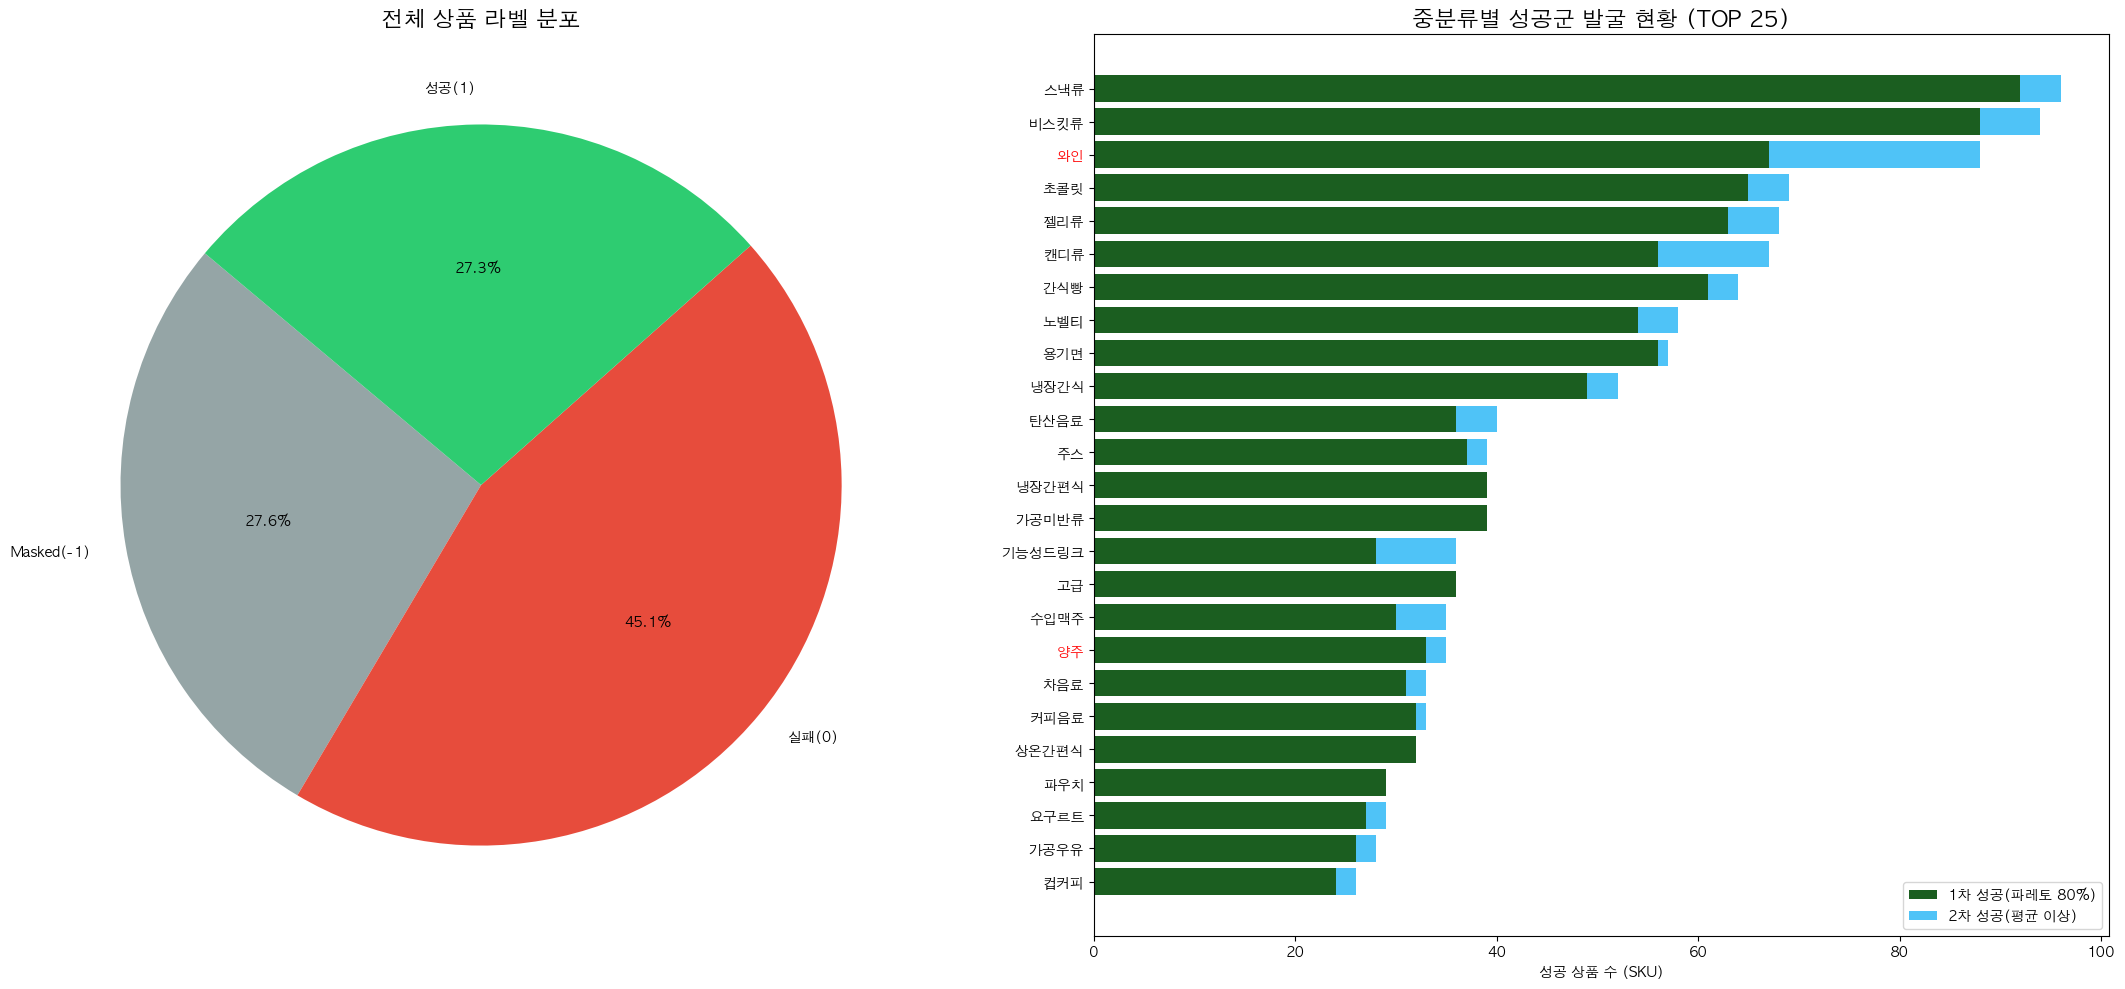

In [13]:
import os
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 경고 무시 (시각화 및 폰트 관련)
warnings.filterwarnings("ignore")

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ────────────────────────────────────────────────────────────
DATA_DIR = "/Users/hajiyoon/workspace/data/processed"
POS_PATH = os.path.join(DATA_DIR, "pos_data_food_final_상품단위변환전.parquet")
B4_PATH = os.path.join(DATA_DIR, "B4_CLEAN_FOOD_ITEM.parquet")
OUTPUT_PATH = os.path.join(DATA_DIR, "LABELS_FINAL_v2.parquet")

# ── 확정된 기준값 ─────────────────────────────────────────────────────────
MASKING_CATS  = ["쌀/잡곡", "시즌케익", "기타", "분말가루", "샐러드모닝랩", "쨈/꿀", "식빵"]
GROUP_A_CATS  = ["와인", "양주", "선물세트", "신선냉동"]
LOCAL_N       = 10
GLOBAL_N      = 50
PARETO        = 0.80

LABEL_SUCCESS = 1
LABEL_FAIL    = 0
LABEL_MASKED  = -1

def create_simulation_data():
    """실제 파일이 없을 경우 시뮬레이션 데이터 생성"""
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR, exist_ok=True)
    
    print("! 데이터 파일이 없어 시뮬레이션 데이터를 생성합니다.")
    
    # B4 시뮬레이션
    categories = ["과자", "음료", "유제품", "라면", "빵", "와인", "양주", "선물세트", "신선냉동", "즉석식품"] + MASKING_CATS
    b4_data = []
    for i in range(1, 5001):
        cat = np.random.choice(categories)
        b4_data.append({
            "상품코드": f"ITEM_{i:04d}",
            "중분류명": cat,
            "소분류명": f"{cat}_소",
            "상품명": f"{cat}_상품_{i}"
        })
    pl.from_dicts(b4_data).write_parquet(B4_PATH)

    # POS 시뮬레이션
    pos_data = []
    for i in range(1, 5001):
        item_id = f"ITEM_{i:04d}"
        qty = int(np.random.exponential(scale=200)) + 1
        amt = qty * np.random.randint(1000, 5000)
        pos_data.append({
            "상품코드": item_id,
            "매출수량": float(qty),
            "매출금액": float(amt)
        })
    pl.from_dicts(pos_data).write_parquet(POS_PATH)

def load_and_aggregate():
    """Polars Lazy Mode를 이용한 데이터 로딩 및 집계"""
    if not os.path.exists(POS_PATH) or not os.path.exists(B4_PATH):
        create_simulation_data()

    print("[1/6] 데이터 로딩 및 상품 단위 집계 중 (Polars Lazy)...")
    collected = (
        pl.scan_parquet(POS_PATH)
        .filter(
            (pl.col("매출수량") > 0) &
            (pl.col("매출금액") > 0)
        )
        .join(
            pl.scan_parquet(B4_PATH)
              .select(["상품코드", "중분류명", "소분류명", "상품명"]),
            on="상품코드", how="inner"
        )
        .group_by(["상품코드", "중분류명", "소분류명", "상품명"])
        .agg([
            pl.col("매출금액").sum().alias("총매출금액"),
            pl.col("매출수량").sum().alias("총매출수량")
        ])
        .collect()
    )
    return collected.to_pandas()

def generate_labels(df):
    """5단계 라벨 생성 로직 적용"""
    print("[2/6] 최종 라벨 생성 로직 적용 중 (5 STEP)...")
    df = df.copy()
    df['label']        = LABEL_MASKED
    df['label_reason'] = ''
    df['success_type'] = 'None' # 시각화 및 분석용

    # ── STEP 1. Masking 카테고리 제외 ──
    mask_cat = df['중분류명'].isin(MASKING_CATS)
    df.loc[mask_cat, 'label_reason'] = '구조적 SKU 부족 카테고리'

    # ── STEP 2. N 기준 미달 → Masked ──
    n_threshold = df['중분류명'].apply(
        lambda c: LOCAL_N if c in GROUP_A_CATS else GLOBAL_N
    )
    mask_n_fail = (~mask_cat) & (df['총매출수량'] < n_threshold)
    df.loc[mask_n_fail, 'label_reason'] = (
        df.loc[mask_n_fail, '총매출수량'].apply(lambda x: f"N 기준 미달 ({int(x)} < ")
        + n_threshold[mask_n_fail].astype(str) + ")"
    )

    # N 통과 상품만 추출 (파레토 적용 대상)
    mask_valid = (~mask_cat) & (df['총매출수량'] >= n_threshold)
    df_valid   = df[mask_valid].copy()

    # ── STEP 3. 파레토 80% → 1차 성공군 ──
    df_valid['label']        = LABEL_FAIL   # 임시 실패 처리
    df_valid['label_reason'] = 'N 기준 통과 / 파레토 미달'

    for cat, group in df_valid.groupby('중분류명'):
        gs    = group.sort_values('총매출금액', ascending=False)
        total = gs['총매출금액'].sum()
        if total == 0: continue
        cum   = gs['총매출금액'].cumsum() / total
        idx   = gs[cum <= PARETO].index
        if len(idx) < len(gs):
            idx = idx.append(pd.Index([gs.index[len(idx)]]))
        
        df_valid.loc[idx, 'label']        = LABEL_SUCCESS
        df_valid.loc[idx, 'label_reason'] = '파레토 80% 1차 성공군'
        df_valid.loc[idx, 'success_type'] = '1차 성공'

    # ── STEP 4. 나머지 20% 구간에서 2차 성공군 ──
    cat_mean = (
        df_valid.groupby('중분류명')['총매출수량']
        .mean()
    )
    df_remain = df_valid[df_valid['label'] == LABEL_FAIL].copy()

    # merge 대신 map 사용 → 원본 인덱스 보존
    df_remain['카테고리_평균'] = df_remain['중분류명'].map(cat_mean)

    success_2nd = df_remain[df_remain['총매출수량'] >= df_remain['카테고리_평균']].index
    df_valid.loc[success_2nd, 'label']        = LABEL_SUCCESS
    df_valid.loc[success_2nd, 'label_reason'] = '카테고리 평균 이상 2차 성공군'
    df_valid.loc[success_2nd, 'success_type'] = '2차 성공'
    df.update(df_valid[['label', 'label_reason', 'success_type']])

        
    return df

def validate_labels(df):
    """생성된 라벨의 학습 적합성 검수"""
    issues  = []
    labeled = df[df['label'] != LABEL_MASKED]
    
    # 검수 1. 학습 가능 기준 성공률 15~30% (2차 성공군 포함 고려)
    if len(labeled) > 0:
        rate = (labeled['label'] == LABEL_SUCCESS).mean()
        if not (0.15 <= rate <= 0.30):
            issues.append(f"⚠️  성공률 {rate:.1%} → 목표 범위(15~25%) 소폭 이탈 확인 필요")
    
    # 검수 2. 성공군 0개 카테고리
    cat_success = labeled.groupby('중분류명')['label'].sum()
    zero_cats   = cat_success[cat_success == 0].index.tolist()
    if zero_cats:
        issues.append(f"⚠️  성공군 0개 카테고리 존재: {zero_cats}")

    # 검수 3. 성공군 3개 미만 카테고리
    low_cats = cat_success[(cat_success > 0) & (cat_success < 3)].index.tolist()
    if low_cats:
        issues.append(f"⚠️  성공군 3개 미만 카테고리: {low_cats}")

    return issues

def visualize_labels(df):
    """시각화 리포트 생성 및 저장"""
    print("[4/6] 시각화 이미지 생성 중...")
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    # [차트 1] 전체 라벨 분포
    dist   = df['label'].value_counts().sort_index()
    labels = {1: '성공(1)', 0: '실패(0)', -1: 'Masked(-1)'}
    dist.index = dist.index.map(labels)
    axes[0].pie(dist, labels=dist.index, autopct='%1.1f%%', startangle=140, 
                colors=['#95a5a6', '#e74c3c', '#2ecc71']) # Masked, 실패, 성공 순서
    axes[0].set_title("전체 상품 라벨 분포", fontsize=16, fontweight='bold')

    # [차트 2] 중분류별 성공군 수 (TOP 25)
    success_df = df[df['label'] == LABEL_SUCCESS].groupby(['중분류명', 'success_type']).size().unstack(fill_value=0)
    if not success_df.empty:
        success_df['total'] = success_df.sum(axis=1)
        success_df = success_df.sort_values('total', ascending=False).head(25)
        
        y_pos = np.arange(len(success_df))
        axes[1].barh(y_pos, success_df['1차 성공'], color='#1b5e20', label='1차 성공(파레토 80%)')
        if '2차 성공' in success_df.columns:
            axes[1].barh(y_pos, success_df['2차 성공'], left=success_df['1차 성공'], color='#4fc3f7', label='2차 성공(평균 이상)')
        
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(success_df.index)
        axes[1].invert_yaxis()
        axes[1].set_xlabel("성공 상품 수 (SKU)")
        axes[1].set_title("중분류별 성공군 발굴 현황 (TOP 25)", fontsize=16, fontweight='bold')
        axes[1].legend(loc='lower right')

        # Group A 카테고리 강조
        for i, cat in enumerate(success_df.index):
            if cat in GROUP_A_CATS:
                axes[1].get_yticklabels()[i].set_color('red')
                axes[1].get_yticklabels()[i].set_weight('bold')

    plt.tight_layout()
    plt.savefig("label_distribution_v2.png", dpi=300)
    print("- 시각화 저장 완료: label_distribution_v2.png")

def print_summary(df, issues):
    """최종 결과 요약 출력"""
    total  = len(df)
    success = (df['label'] == LABEL_SUCCESS).sum()
    fail    = (df['label'] == LABEL_FAIL).sum()
    masked  = (df['label'] == LABEL_MASKED).sum()
    
    success_1st = (df['success_type'] == '1차 성공').sum()
    success_2nd = (df['success_type'] == '2차 성공').sum()
    
    n_fail   = df['label_reason'].str.contains('N 기준 미달').sum()
    mask_cat = df['label_reason'].str.contains('구조적 SKU').sum()

    print("\n" + "="*60)
    print(" [최종 라벨 생성 결과 v2]")
    print("="*60)
    print(f"전체 상품 수:              {total:,}개")
    
    print(f"\n[라벨 분포]")
    print(f"  성공  (label=  1):       {success:,}개  ({success/total*100:1.1f}%)")
    print(f"    └ 1차 성공군 (파레토):  {success_1st:,}개")
    print(f"    └ 2차 성공군 (평균):      {success_2nd:,}개")
    print(f"  실패  (label=  0):       {fail:,}개  ({fail/total*100:1.1f}%)")
    print(f"  Masked(label= -1):       {masked:,}개  ({masked/total*100:1.1f}%)")
    print(f"    └ N 기준 미달:          {n_fail:,}개")
    print(f"    └ Masking 카테고리:       {mask_cat:,}개")

    train_total = success + fail
    if train_total > 0:
        print(f"\n[학습 가능 기준 성공률]: {success/train_total*100:1.1f}%")
        print(f"  (성공 / (성공 + 실패))")

    print(f"\n[검수 결과]")
    if not issues:
        print("이상 없음 ✅")
    else:
        for issue in issues:
            print(issue)

    print(f"\n저장 완료: {os.path.basename(OUTPUT_PATH)}")
    print("="*60)

if __name__ == "__main__":
    # 1. 데이터 로딩 및 집계
    df_raw = load_and_aggregate()

    # 2. 라벨 생성
    df_labeled = generate_labels(df_raw)

    # 3. 검수
    val_issues = validate_labels(df_labeled)

    # 4. 시각화
    visualize_labels(df_labeled)

    # 5. 콘솔 출력
    print_summary(df_labeled, val_issues)

    # 6. Parquet 저장
    print(f"[6/6] 최종 파일 저장 중...")
    pl.from_pandas(df_labeled).write_parquet(OUTPUT_PATH)


이 2,071개가 왜 N 미달인지 생각해보면:

판매량 50개 미만 (Group B 기준)
= 편의점에서 거의 팔리지 않은 상품

→ 이런 상품이 성공인지 실패인지
  판단하는 것 자체가 무의미

→ 오히려 이걸 실패(0)로 넣으면
  "조금 팔린 것 = 실패"로
  AI가 잘못 학습

In [14]:
# 선물세트 라벨 분포 확인
result = (
    pl.scan_parquet('/Users/hajiyoon/workspace/data/processed/LABELS_FINAL_v2.parquet')
    .filter(pl.col("중분류명") == "선물세트")
    .group_by("label")
    .agg(pl.len().alias("count"))
    .collect()
)
print(result)

shape: (3, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i64   ┆ u32   │
╞═══════╪═══════╡
│ 0     ┆ 9     │
│ -1    ┆ 21    │
│ 1     ┆ 2     │
└───────┴───────┘


선물세트는 Group A (Local N=10)

Masked 21개:
  N=10 미달 상품들
  → 판매량 10개 미만

파레토 적용 대상: 11개 (9+2)
파레토 80% 통과: 2개

→ 11개 중 2개만 매출 80% 차지
→ 선물세트 내 소수 독점 구조 확인

결론: 선물세트도 마스킹처리 하자. 그룹 A에서도 제거하자. 어때요?

In [16]:
import polars as pl

pl.Config.set_tbl_rows(-1)    # 행 생략 없이 전체 표시
pl.Config.set_tbl_cols(-1)    # 컬럼 생략 없이 전체 표시
pl.Config.set_fmt_str_lengths(50)  # 문자열 잘림 방지

result = (
    pl.scan_parquet('/Users/hajiyoon/workspace/data/processed/LABELS_FINAL_v2.parquet')
    .filter(pl.col("label_reason").str.contains("N 기준 미달"))
    .group_by("중분류명")
    .agg(pl.len().alias("n_미달수"))
    .join(
        pl.scan_parquet('/Users/hajiyoon/workspace/data/processed/LABELS_FINAL_v2.parquet')
        .group_by("중분류명")
        .agg(pl.len().alias("전체수")),
        on="중분류명", how="left"
    )
    .with_columns(
        (pl.col("n_미달수") / pl.col("전체수") * 100).round(1).alias("n_미달비율(%)")
    )
    .sort("n_미달비율(%)", descending=True)
    .collect()
)

print(result)

shape: (90, 4)
┌───────────────┬──────────┬────────┬───────────────┐
│ 중분류명      ┆ n_미달수 ┆ 전체수 ┆ n_미달비율(%) │
│ ---           ┆ ---      ┆ ---    ┆ ---           │
│ str           ┆ u32      ┆ u32    ┆ f64           │
╞═══════════════╪══════════╪════════╪═══════════════╡
│ 선물세트      ┆ 21       ┆ 32     ┆ 65.6          │
│ 홈타입        ┆ 15       ┆ 25     ┆ 60.0          │
│ 야채          ┆ 54       ┆ 104    ┆ 51.9          │
│ 소스류        ┆ 24       ┆ 48     ┆ 50.0          │
│ 장류          ┆ 13       ┆ 26     ┆ 50.0          │
│ 리쿼          ┆ 12       ┆ 25     ┆ 48.0          │
│ 캔디류        ┆ 190      ┆ 399    ┆ 47.6          │
│ 호빵          ┆ 9        ┆ 19     ┆ 47.4          │
│ 고급          ┆ 83       ┆ 178    ┆ 46.6          │
│ 노벨티        ┆ 164      ┆ 352    ┆ 46.6          │
│ 기타전통주    ┆ 24       ┆ 52     ┆ 46.2          │
│ 와인          ┆ 199      ┆ 431    ┆ 46.2          │
│ 컨셉카페      ┆ 9        ┆ 20     ┆ 45.0          │
│ 푸드 간편식   ┆ 14       ┆ 32     ┆ 43.8          │
│ 소주          ┆

n 미달 비율이 중분류별로 얼마나 되는지 확인해본것. 


1. 소규모 카테고리 (전체 SKU 수 자체가 적음)

   홈타입(25개), 장류(26개), 리쿼(25개) 등

   → 비율이 높아 보이지만 절대 수가 작음

   → 큰 문제 없음

2. 다품종 저판매 카테고리

   캔디류(190/399), 노벨티(164/352)

   → SKU 종류는 많지만
     실제로 판매되는 건 소수

   → N 미달이 많은 게 정상

3. Group A 고단가 카테고리

   와인(46.2%), 양주(36.2%)

   → Local N=10으로 완화했음에도 높음

   → 고단가라 원래 적게 팔리는 구조

   → 성공군은 충분히 확보됨

→ 전체적으로 N 기준 미달이
  학습에 방해가 되는 수준이 아님 ✅
  
→ 오히려 노이즈를 걸러내는 역할 수행 ✅